# Results After Filtering — Module Similarity & Pathway Survival

Runs `tissue_specific_filtering.py` across thresholds for IID and STRING (GTEx and PaxDB sources), then evaluates the resulting filtered networks:
1. Non-brain tissue-specific genes are preferentially removed; brain-specific genes are retained
2. KEGG pathway gene survival across thresholds (with an unfiltered-network coverage baseline)
3. Downstream disease-module Jaccard similarity across pipeline runs

## 1 — Setup

In [1]:
import subprocess
import sys
import os
from pathlib import Path

import graph_tool.all as gt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import requests
from gprofiler import GProfiler

REPO_ROOT = Path(".").resolve()
SCRIPT    = REPO_ROOT / "diseasemodulediscovery/bin/context_specific_filtering.py"
BIN_DIR   = SCRIPT.parent
NET_DIR   = REPO_ROOT / "data/alzheimer_symbol_runs/alzheimer_run_symbol_threshold_1/input/networks"
EXPR_FILE = REPO_ROOT / "data/expression_by_tissue.gct"
OUT_ROOT  = REPO_ROOT / "sanity_check_outputs"
FILTERING_FILE_CACHE = REPO_ROOT / "data"

TISSUE     = "Brain_Hippocampus"
THRESHOLDS = [0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
NETWORKS   = {
    "iid":    NET_DIR / "iid.human.Symbol.gt",
    "string": NET_DIR / "string.human_links_v12_0_min900.Symbol.gt",
}

OUT_ROOT.mkdir(exist_ok=True)
print("Script:", SCRIPT)
print("Expression file:", EXPR_FILE)
print("Networks:", {k: v.name for k, v in NETWORKS.items()})


def resolve_filtering_file(source, context):
    """context_specific_filtering.py no longer downloads its own expression
    data itself -- that moved to Nextflow's downloadFilteringFile()
    (subworkflows/local/network_filtering/main.nf) as of the "refactored file
    download to be handled by nextflow" commit, so the script now requires an
    already-staged file via --filtering_file. This mirrors that same download
    logic for running the script directly here, caching into data/ (reusing
    files already there, e.g. TCGA-GBM.star_tpm.tsv.gz)."""
    if source == "GTEx":
        return EXPR_FILE
    elif source == "PAXDB":
        dest = FILTERING_FILE_CACHE / f"9606-{context.upper()}-integrated.txt"
        url  = f"https://pax-db.org/downloads/6.1/datasets/9606/9606-{context.upper()}-integrated.txt"
    elif source == "TCGA":
        cancer_type = context.upper().removeprefix("TCGA_")
        dest = FILTERING_FILE_CACHE / f"TCGA-{cancer_type}.star_tpm.tsv.gz"
        url  = f"https://gdc-hub.s3.us-east-1.amazonaws.com/download/TCGA-{cancer_type}.star_tpm.tsv.gz"
    else:
        raise ValueError(f"Unknown filtering_source: {source!r}")

    if not dest.exists():
        response = requests.get(url, stream=True)
        response.raise_for_status()
        with open(dest, "wb") as f:
            for chunk in response.iter_content(chunk_size=8192):
                f.write(chunk)
        print(f"Downloaded {source} filtering file -> {dest}")
    return dest

Script: /Users/motan/Uni/ba/diseasemodulediscovery/bin/context_specific_filtering.py
Expression file: /Users/motan/Uni/ba/data/expression_by_tissue.gct
Networks: {'iid': 'iid.human.Symbol.gt', 'string': 'string.human_links_v12_0_min900.Symbol.gt'}


## 2 — Run `tissue_specific_filtering.py` for each threshold × network (GTEx)

In [2]:
env = {**os.environ, "PYTHONPATH": str(BIN_DIR)}
filtering_file = resolve_filtering_file("GTEx", TISSUE)

run_index = {}  # (net_name, threshold) -> output_dir

for net_name, net_path in NETWORKS.items():
    for thr in THRESHOLDS:
        tag    = f"thr_{str(thr).replace('.', '_')}"
        outdir = OUT_ROOT / net_name / tag
        outdir.mkdir(parents=True, exist_ok=True)

        filtered_gt = outdir / f"{net_path.stem}.{TISSUE}.GTEx.{thr}.gt"
        if filtered_gt.exists():
            print(f"[skip] {net_name} thr={thr}  (already exists)")
            run_index[(net_name, thr)] = outdir
            continue

        cmd = [
            sys.executable, str(SCRIPT),
            "--network",                str(net_path),
            "--context",                TISSUE,
            "--threshold",              str(thr),
            "--filtering_source",       "GTEx",
            "--custom_expression_file", "null",
            "--filtering_file",        str(filtering_file),
            "--id_space",               "symbol",
        ]
        result = subprocess.run(cmd, cwd=str(outdir), env=env,
                                capture_output=True, text=True)
        if result.returncode != 0:
            print(f"ERROR {net_name} thr={thr}:\n{result.stderr[-2000:]}")
        else:
            print(f"[done] {net_name} thr={thr}")
        run_index[(net_name, thr)] = outdir

print("All runs complete.")

[skip] iid thr=0.1  (already exists)
[skip] iid thr=0.5  (already exists)
[skip] iid thr=1.0  (already exists)
[skip] iid thr=2.0  (already exists)
[skip] iid thr=5.0  (already exists)
[skip] iid thr=10.0  (already exists)
[skip] string thr=0.1  (already exists)
[skip] string thr=0.5  (already exists)
[skip] string thr=1.0  (already exists)
[skip] string thr=2.0  (already exists)
[skip] string thr=5.0  (already exists)
[skip] string thr=10.0  (already exists)
All runs complete.


## 3 — Collect filtering statistics from script output

In [3]:
stats_rows = []
for (net_name, thr), outdir in run_index.items():
    tsv = outdir / "filtering_statistic.tsv"
    if not tsv.exists():
        print(f"Missing: {tsv}")
        continue
    row = pd.read_csv(tsv, sep="\t").iloc[0].to_dict()
    row["network_name"] = net_name
    row["threshold"]    = thr
    stats_rows.append(row)

stats_df = pd.DataFrame(stats_rows)
# clean HTML from context column if present
stats_df["context"] = stats_df["context"].str.extract(r'>([^<]+)<', expand=False).fillna(stats_df["context"])
stats_df.sort_values(["network_name", "threshold"], inplace=True)
stats_df.head(12)

,network,context,genes_in_context,genes_not_in_network_absolute,genes_not_in_network_relative,genes_not_in_expression_file_absolute,genes_not_in_expression_file_relative,genes_filtered_by_threshold_absolute,genes_filtered_by_threshold_relative,network_name,threshold
0,iid.human.Symbol.Brain_Hippocampus.GTEx.0.1,Brain_Hippocampus,19182,21143,0.537908,166,0.009057,2878,0.157019,iid,0.1
1,iid.human.Symbol.Brain_Hippocampus.GTEx.0.5,Brain_Hippocampus,15544,21143,0.537908,166,0.009057,4478,0.244312,iid,0.5
2,iid.human.Symbol.Brain_Hippocampus.GTEx.1.0,Brain_Hippocampus,13862,21143,0.537908,166,0.009057,5454,0.297561,iid,1.0
3,iid.human.Symbol.Brain_Hippocampus.GTEx.2.0,Brain_Hippocampus,11865,21143,0.537908,166,0.009057,6911,0.377053,iid,2.0
4,iid.human.Symbol.Brain_Hippocampus.GTEx.5.0,Brain_Hippocampus,8423,21143,0.537908,166,0.009057,10005,0.545856,iid,5.0
5,iid.human.Symbol.Brain_Hippocampus.GTEx.10.0,Brain_Hippocampus,5444,21143,0.537908,166,0.009057,12865,0.701893,iid,10.0
6,string.human_links_v12_0_min900.Symbol.Brain_H...,Brain_Hippocampus,19182,27477,0.699054,98,0.008217,1506,0.126268,string,0.1
7,string.human_links_v12_0_min900.Symbol.Brain_H...,Brain_Hippocampus,15544,27477,0.699054,98,0.008217,2488,0.208602,string,0.5
8,string.human_links_v12_0_min900.Symbol.Brain_H...,Brain_Hippocampus,13862,27477,0.699054,98,0.008217,3055,0.256142,string,1.0
9,string.human_links_v12_0_min900.Symbol.Brain_H...,Brain_Hippocampus,11865,27477,0.699054,98,0.008217,3881,0.325396,string,2.0


## 4 — Extract node sets from original and filtered networks

In [4]:
def node_names(gt_path):
    g = gt.load_graph(str(gt_path))
    return {g.vp["name"][v] for v in g.iter_vertices()}

# cache original node sets
original_nodes = {name: node_names(path) for name, path in NETWORKS.items()}
print({k: len(v) for k, v in original_nodes.items()})

# collect retained and removed sets per (network, threshold)
node_sets = {}  # (net_name, thr) -> {"retained": set, "removed": set}
for (net_name, thr), outdir in run_index.items():
    net_path    = NETWORKS[net_name]
    filtered_gt = outdir / f"{net_path.stem}.{TISSUE}.GTEx.{thr}.gt"
    retained    = node_names(filtered_gt)
    removed     = original_nodes[net_name] - retained
    node_sets[(net_name, thr)] = {"retained": retained, "removed": removed}

print("Node sets collected for", len(node_sets), "runs.")

{'iid': 18329, 'string': 11927}


Node sets collected for 12 runs.


## 5 — Load GCT expression data (all tissues)

In [5]:
gct = pd.read_csv(EXPR_FILE, sep="\t", skiprows=2, header=0)
# Description column contains gene symbols; rename for clarity
gct = gct.rename(columns={"Name": "ensembl", "Description": "symbol"})
# strip Ensembl version suffixes
gct["ensembl"] = gct["ensembl"].str.split(".").str[0]

tissue_cols = [c for c in gct.columns if c not in ("ensembl", "symbol")]
print(f"{len(gct):,} genes × {len(tissue_cols)} tissues")
print("Brain tissues:", [t for t in tissue_cols if t.startswith("Brain")])

74,628 genes × 68 tissues
Brain tissues: ['Brain_Amygdala', 'Brain_Anterior_cingulate_cortex_BA24', 'Brain_Caudate_basal_ganglia', 'Brain_Cerebellar_Hemisphere', 'Brain_Cerebellum', 'Brain_Cortex', 'Brain_Frontal_Cortex_BA9', 'Brain_Hippocampus', 'Brain_Hypothalamus', 'Brain_Nucleus_accumbens_basal_ganglia', 'Brain_Putamen_basal_ganglia', 'Brain_Spinal_cord_cervical_c-1', 'Brain_Substantia_nigra']


## 6 — Tissue Contamination Analysis

For each reference non-brain tissue, define tissue-specific genes (TPM > 1 there, < 0.5 in Brain_Hippocampus) and measure what fraction are removed by the filter at each threshold.

In [6]:
REF_TISSUES = [
    "Liver", "Muscle_Skeletal", "Whole_Blood",
    "Kidney_Cortex", "Pancreas", "Heart_Left_Ventricle", "Lung",
]

# We use STRING as the reference network (smaller, cleaner)
NET = "string"
all_nodes = original_nodes[NET]

contamination_rows = []
for ref_tissue in REF_TISSUES:
    # tissue-specific: expressed in ref_tissue but not in brain
    tissue_specific_mask = (gct[ref_tissue] > 1) & (gct[TISSUE] < 0.5)
    tissue_specific_symbols = set(gct.loc[tissue_specific_mask, "symbol"].dropna())
    in_network = tissue_specific_symbols & all_nodes
    for thr in THRESHOLDS:
        removed = node_sets[(NET, thr)]["removed"]
        frac = len(tissue_specific_symbols & removed) / len(in_network) if in_network else 0.0
        contamination_rows.append({"tissue": ref_tissue, "threshold": thr,
                                    "frac_removed": frac,
                                    "n_tissue_specific_in_network": len(in_network)})

# positive control: brain-specific genes retained
brain_high = gct[TISSUE] > 1
other_low  = (gct[tissue_cols].drop(columns=[TISSUE]).max(axis=1) < 0.5)
brain_specific_symbols = set(gct.loc[brain_high & other_low, "symbol"].dropna())
brain_in_network = brain_specific_symbols & all_nodes
print(f"Brain-specific genes in network: {len(brain_in_network)}")

brain_retention = []
for thr in THRESHOLDS:
    retained = node_sets[(NET, thr)]["retained"]
    frac = len(brain_specific_symbols & retained) / len(brain_in_network) if brain_in_network else 0.0
    brain_retention.append({"threshold": thr, "frac_retained": frac})

cont_df   = pd.DataFrame(contamination_rows)
brain_ret = pd.DataFrame(brain_retention)
cont_df.head()

Brain-specific genes in network: 0


,tissue,threshold,frac_removed,n_tissue_specific_in_network
0,Liver,0.1,0.466527,478
1,Liver,0.5,1.000000,478
2,Liver,1.0,1.000000,478
3,Liver,2.0,1.000000,478
4,Liver,5.0,1.000000,478


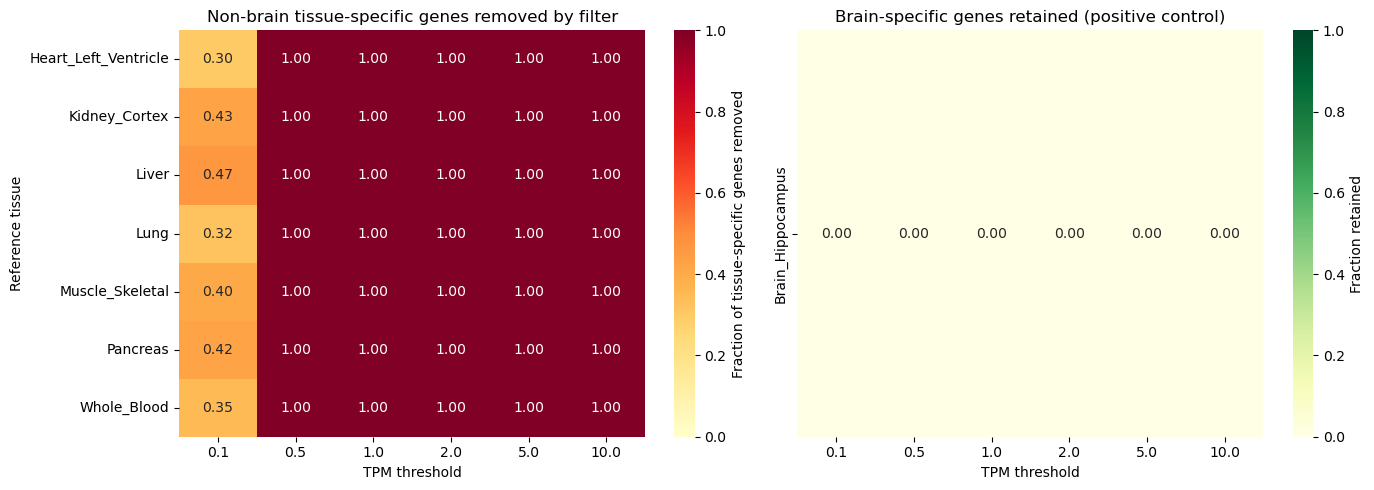

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: non-brain tissue removal heatmap
pivot = cont_df.pivot(index="tissue", columns="threshold", values="frac_removed")
sns.heatmap(
    pivot, ax=axes[0], annot=True, fmt=".2f",
    cmap="YlOrRd", vmin=0, vmax=1,
    cbar_kws={"label": "Fraction of tissue-specific genes removed"},
)
axes[0].set_title("Non-brain tissue-specific genes removed by filter")
axes[0].set_xlabel("TPM threshold")
axes[0].set_ylabel("Reference tissue")

# Right: brain-specific genes retained
pivot_b = brain_ret.set_index("threshold")[["frac_retained"]].T
sns.heatmap(
    pivot_b, ax=axes[1], annot=True, fmt=".2f",
    cmap="YlGn", vmin=0, vmax=1,
    cbar_kws={"label": "Fraction retained"},
)
axes[1].set_title("Brain-specific genes retained (positive control)")
axes[1].set_xlabel("TPM threshold")
axes[1].set_ylabel("")
axes[1].set_yticks([0.5])
axes[1].set_yticklabels(["Brain_Hippocampus"])

plt.tight_layout()
plt.savefig(OUT_ROOT / "tissue_contamination_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

## 7 — Tissue-Specific Pathway Gene Survival Across Thresholds (GTEx)

For a curated set of tissue-specific KEGG pathways, fetch the member genes and track how many remain in the filtered network at each threshold.
- **Non-brain pathways** (Liver, Pancreas, Heart, Blood, Kidney): expect progressive removal as threshold rises.
- **Brain pathways** (positive control): expect genes to remain.
- **Unfiltered column**: fraction of each pathway's full KEGG gene set already present in the raw, unfiltered network, independent of any threshold.

In [8]:
import requests
import re
import json

PATHWAYS = {
    # Non-brain — expect removal by brain filter
    "Pancrease secretion (Pancreas)":           "hsa04972",
    "Bile secretion (Liver)":                 "hsa04976",
    "Drug metabolism CYP450 (Liver)":         "hsa00982",
    "Complement & coagulation (Blood)":       "hsa04610",
    "T cell receptor signaling (Immune)":     "hsa04660",
    "Cardiac muscle contraction (Heart)":     "hsa04260",
    "Aldosterone Na-reabsorption (Kidney)":   "hsa04960",
    # Brain — positive control, expect retention
    "Synaptic vesicle cycle (Brain)":         "hsa04721",
    "Dopaminergic synapse (Brain)":           "hsa04728",
    "Glutamatergic synapse (Brain)":          "hsa04724",
    "GABAergic synapse (Brain)":              "hsa04727",
    "Alzheimer disease (Brain)":              "hsa05010",
}

CACHE_FILE = OUT_ROOT / "kegg_pathway_genes.json"

def fetch_kegg_genes(pathway_id):
    """Return list of HGNC symbols from the GENE section of a KEGG pathway."""
    text = requests.get(f"https://rest.kegg.jp/get/{pathway_id}", timeout=30).text
    genes, in_gene = [], False
    for line in text.splitlines():
        if line.startswith("GENE"):
            in_gene = True
        elif in_gene and not line.startswith(" "):
            break
        if in_gene:
            m = re.search(r'\d+\s+(\S+);', line)
            if m:
                genes.append(m.group(1))
    return genes

if CACHE_FILE.exists():
    with open(CACHE_FILE) as f:
        pathway_genes = json.load(f)
    print("Loaded pathway gene lists from cache.")
else:
    pathway_genes = {}
    for name, pid in PATHWAYS.items():
        genes = fetch_kegg_genes(pid)
        pathway_genes[name] = genes
        print(f"  {pid}  {name}: {len(genes)} genes")
    with open(CACHE_FILE, "w") as f:
        json.dump(pathway_genes, f, indent=2)
    print("Cached to", CACHE_FILE)

for name, genes in pathway_genes.items():
    print(f"  {len(genes):3d}  {name}")


Loaded pathway gene lists from cache.
  103  Pancrease secretion (Pancreas)
   90  Bile secretion (Liver)
   71  Drug metabolism CYP450 (Liver)
   89  Complement & coagulation (Blood)
  122  T cell receptor signaling (Immune)
   87  Cardiac muscle contraction (Heart)
   38  Aldosterone Na-reabsorption (Kidney)
   79  Synaptic vesicle cycle (Brain)
  133  Dopaminergic synapse (Brain)
  116  Glutamatergic synapse (Brain)
   89  GABAergic synapse (Brain)
  388  Alzheimer disease (Brain)
  533  Pathways in cancer (Cancer)
  158  Cell cycle (Cancer)
   75  p53 signaling pathway (Cancer)
  361  PI3K-Akt signaling pathway (Cancer)
  301  MAPK signaling pathway (Cancer)
   76  Glioma (Glioblastoma)


In [9]:
# ── Compute fraction of pathway genes surviving in the filtered network ──────
NON_BRAIN = [k for k in PATHWAYS if "(Brain)" not in k]
BRAIN     = [k for k in PATHWAYS if "(Brain)" in k]

rows = []
for net_name in NETWORKS:
    for pathway_name, genes in pathway_genes.items():
        gene_set      = set(genes)
        in_network    = gene_set & original_nodes[net_name]
        if not in_network:
            continue
        # "unfiltered" column: fraction of ALL pathway genes present in the
        # raw, unfiltered network — checks whether the pathway is even fully
        # covered by the network before any tissue filtering is applied.
        rows.append({
            "network":  net_name,
            "pathway":  pathway_name,
            "threshold": "unfiltered",
            "n_in_network": len(in_network),
            "n_surviving":  len(in_network),
            "frac_surviving": len(in_network) / len(gene_set),
        })
        for thr in THRESHOLDS:
            retained      = node_sets[(net_name, thr)]["retained"]
            n_surviving   = len(in_network & retained)
            rows.append({
                "network":  net_name,
                "pathway":  pathway_name,
                "threshold": thr,
                "n_in_network": len(in_network),
                "n_surviving":  n_surviving,
                "frac_surviving": n_surviving / len(in_network),
            })

survival_df = pd.DataFrame(rows)
print(survival_df.groupby(["network", "pathway"])[["n_in_network"]].first().to_string())


                                              n_in_network
network pathway                                           
iid     Aldosterone Na-reabsorption (Kidney)            37
        Alzheimer disease (Brain)                      383
        Bile secretion (Liver)                          89
        Cardiac muscle contraction (Heart)              87
        Cell cycle (Cancer)                            156
        Complement & coagulation (Blood)                88
        Dopaminergic synapse (Brain)                   132
        Drug metabolism CYP450 (Liver)                  68
        GABAergic synapse (Brain)                       89
        Glioma (Glioblastoma)                           75
        Glutamatergic synapse (Brain)                  115
        MAPK signaling pathway (Cancer)                300
        PI3K-Akt signaling pathway (Cancer)            358
        Pancrease secretion (Pancreas)                 100
        Pathways in cancer (Cancer)                    5

In [10]:
def pathway_survival_heatmap(df, net_name, node_sets, original_nodes, outfile=None,
                              filter_label="Brain_Hippocampus filter", xlabel="TPM threshold",
                              ax=None, cbar=True, cbar_ax=None, yticklabels=True, title=None,
                              show_unfiltered=True):
    """Heatmap: rows = whole-network retention control + pathways (non-brain then brain),
    cols = unfiltered + thresholds, values = fraction surviving.

    Pass `ax` (and optionally `cbar_ax`) to draw into an existing figure/panel
    instead of creating a standalone one — used to combine the GTEx and PaxDB
    panels for the same network into a single figure with one shared colorbar."""
    pivot = df[df["network"] == net_name].pivot(
        index="pathway", columns="threshold", values="frac_surviving"
    )
    numeric_thresholds = sorted(c for c in pivot.columns if c != "unfiltered")
    col_order = (["unfiltered"] if show_unfiltered and "unfiltered" in pivot.columns else []) + numeric_thresholds
    pivot = pivot[col_order]

    ordered     = [p for p in NON_BRAIN + BRAIN if p in pivot.index]
    pivot       = pivot.reindex(ordered)
    n_non_brain = sum(1 for p in ordered if "(Brain)" not in p)

    # Control row: fraction of the WHOLE (unfiltered) network's nodes still
    # present after filtering, independent of any pathway. Unlike the
    # per-pathway rows below (which are normalized to genes present in the
    # network), this tracks overall filtering strength directly, so it
    # sanity-checks whether pathway survival differences reflect the filter
    # itself rather than pathway-specific quirks.
    control_label = "Whole network (% nodes retained)"
    n_all_nodes = len(original_nodes[net_name])
    control_row = {"unfiltered": 1.0}
    for thr in numeric_thresholds:
        control_row[thr] = len(node_sets[(net_name, thr)]["retained"]) / n_all_nodes
    control_row = pd.Series(control_row)[col_order]
    pivot   = pd.concat([control_row.to_frame(control_label).T, pivot])
    ordered = [control_label] + ordered

    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(9, max(5, len(ordered) * 0.55)), dpi=200)
    sns.heatmap(
        pivot, ax=ax,
        annot=True, fmt=".2f", annot_kws={"fontsize": 11},
        cmap="viridis", vmin=0, vmax=1,
        linewidths=0.4, linecolor="#dddddd",
        cbar=cbar, cbar_ax=cbar_ax,
        cbar_kws={"label": "Fraction of pathway genes still in filtered network"} if cbar else {},
        yticklabels=yticklabels,
    )
    ax.tick_params(axis="x", labelsize=11)
    if cbar:
        cbar_obj = ax.collections[0].colorbar
        cbar_obj.ax.yaxis.label.set_size(12)
        cbar_obj.ax.tick_params(labelsize=10)
    ax.axhline(1, color="#3060c0", lw=2)              # separates control row from pathways
    ax.axhline(1 + n_non_brain, color="black", lw=2)  # separates non-brain from brain pathways
    if "unfiltered" in col_order:
        ax.axvline(1, color="black", lw=2)

    # Color y-tick labels instead of floating text (avoids colorbar overlap)
    if yticklabels:
        for tick, label in zip(ax.get_yticklabels(), ordered):
            if label == control_label:
                tick.set_color("#3060c0")
            else:
                tick.set_color("#b03030" if "(Brain)" not in label else "#1a6e1a")
            tick.set_fontweight("bold")
            tick.set_fontsize(11)

    if title is None:
        title = (f"{net_name.upper()} — pathway gene survival after {filter_label}\n"
                 r"$\bf{Blue\ label}$: whole-network retention (control)  |  "
                 r"$\bf{Red\ labels}$: non-brain (should drop)  |  "
                 r"$\bf{Green\ labels}$: brain (positive control)")
    ax.set_title(title, fontsize=13)
    ax.set_xlabel(f"{xlabel}", fontsize=12)
    ax.set_ylabel("")

    if standalone:
        plt.tight_layout()
        if outfile:
            plt.savefig(outfile, dpi=150, bbox_inches="tight")
        plt.show()
    return ax

## 8 — PaxDB (BRAIN): Tissue-Specific Pathway Gene Survival Across Thresholds

Same analysis as Section 7, but using PaxDB integrated protein abundance (ppm) for `BRAIN` instead of GTEx TPM for `Brain_Hippocampus`. Uses the pipeline script's native `--filtering_source PAXDB`, so no local expression file is needed. Reuses `original_nodes`, `PATHWAYS`, and `pathway_genes` from Section 7 — only the filtering source and threshold scale change.

In [11]:
PAXDB_TISSUE     = "BRAIN"
PAXDB_THRESHOLDS = [0.1, 0.5, 1.0, 2.0, 5.0 ,10.0]  # ppm
PAXDB_OUT_ROOT   = OUT_ROOT / "paxdb"
PAXDB_OUT_ROOT.mkdir(exist_ok=True)

print("PaxDB tissue:", PAXDB_TISSUE)
print("PaxDB thresholds (ppm):", PAXDB_THRESHOLDS)


PaxDB tissue: BRAIN
PaxDB thresholds (ppm): [0.1, 0.5, 1.0, 2.0, 5.0, 10.0]


In [12]:
paxdb_filtering_file = resolve_filtering_file("PAXDB", PAXDB_TISSUE)

paxdb_run_index = {}  # (net_name, threshold) -> output_dir

for net_name, net_path in NETWORKS.items():
    for thr in PAXDB_THRESHOLDS:
        tag    = f"thr_{str(thr).replace('.', '_')}"
        outdir = PAXDB_OUT_ROOT / net_name / tag
        outdir.mkdir(parents=True, exist_ok=True)

        filtered_gt = outdir / f"{net_path.stem}.{PAXDB_TISSUE}.PAXDB.{thr}.gt"
        if filtered_gt.exists():
            print(f"[skip] {net_name} thr={thr}  (already exists)")
            paxdb_run_index[(net_name, thr)] = outdir
            continue

        cmd = [
            sys.executable, str(SCRIPT),
            "--network",                str(net_path),
            "--context",                PAXDB_TISSUE,
            "--threshold",              str(thr),
            "--filtering_source",       "PAXDB",
            "--custom_expression_file", "null",
            "--filtering_file",        str(paxdb_filtering_file),
            "--id_space",               "symbol",
        ]
        result = subprocess.run(cmd, cwd=str(outdir), env=env,
                                capture_output=True, text=True)
        if result.returncode != 0:
            print(f"ERROR {net_name} thr={thr}:\n{result.stderr[-2000:]}")
        else:
            print(f"[done] {net_name} thr={thr}")
        paxdb_run_index[(net_name, thr)] = outdir

print("All PaxDB runs complete.")


[skip] iid thr=0.1  (already exists)
[skip] iid thr=0.5  (already exists)
[skip] iid thr=1.0  (already exists)
[skip] iid thr=2.0  (already exists)
[skip] iid thr=5.0  (already exists)
[skip] iid thr=10.0  (already exists)
[skip] string thr=0.1  (already exists)
[skip] string thr=0.5  (already exists)
[skip] string thr=1.0  (already exists)
[skip] string thr=2.0  (already exists)
[skip] string thr=5.0  (already exists)
[skip] string thr=10.0  (already exists)
All PaxDB runs complete.


In [13]:
paxdb_node_sets = {}  # (net_name, thr) -> {"retained": set, "removed": set}
for (net_name, thr), outdir in paxdb_run_index.items():
    net_path    = NETWORKS[net_name]
    filtered_gt = outdir / f"{net_path.stem}.{PAXDB_TISSUE}.PAXDB.{thr}.gt"
    retained    = node_names(filtered_gt)
    removed     = original_nodes[net_name] - retained
    paxdb_node_sets[(net_name, thr)] = {"retained": retained, "removed": removed}

print("Node sets collected for", len(paxdb_node_sets), "PaxDB runs.")


Node sets collected for 12 PaxDB runs.


In [14]:
paxdb_rows = []
for net_name in NETWORKS:
    for pathway_name, genes in pathway_genes.items():
        gene_set   = set(genes)
        in_network = gene_set & original_nodes[net_name]
        if not in_network:
            continue
        paxdb_rows.append({
            "network":  net_name,
            "pathway":  pathway_name,
            "threshold": "unfiltered",
            "n_in_network": len(in_network),
            "n_surviving":  len(in_network),
            "frac_surviving": len(in_network) / len(gene_set),
        })
        for thr in PAXDB_THRESHOLDS:
            retained    = paxdb_node_sets[(net_name, thr)]["retained"]
            n_surviving = len(in_network & retained)
            paxdb_rows.append({
                "network":  net_name,
                "pathway":  pathway_name,
                "threshold": thr,
                "n_in_network": len(in_network),
                "n_surviving":  n_surviving,
                "frac_surviving": n_surviving / len(in_network),
            })

paxdb_survival_df = pd.DataFrame(paxdb_rows)
print(paxdb_survival_df.groupby(["network", "pathway"])[["n_in_network"]].first().to_string())


                                              n_in_network
network pathway                                           
iid     Aldosterone Na-reabsorption (Kidney)            37
        Alzheimer disease (Brain)                      383
        Bile secretion (Liver)                          89
        Cardiac muscle contraction (Heart)              87
        Cell cycle (Cancer)                            156
        Complement & coagulation (Blood)                88
        Dopaminergic synapse (Brain)                   132
        Drug metabolism CYP450 (Liver)                  68
        GABAergic synapse (Brain)                       89
        Glioma (Glioblastoma)                           75
        Glutamatergic synapse (Brain)                  115
        MAPK signaling pathway (Cancer)                300
        PI3K-Akt signaling pathway (Cancer)            358
        Pancrease secretion (Pancreas)                 100
        Pathways in cancer (Cancer)                    5

/var/folders/c3/7nxlprcs7lz9sl8c6_mdhy2w0000gn/T/ipykernel_89079/1794678940.py:30: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.94])


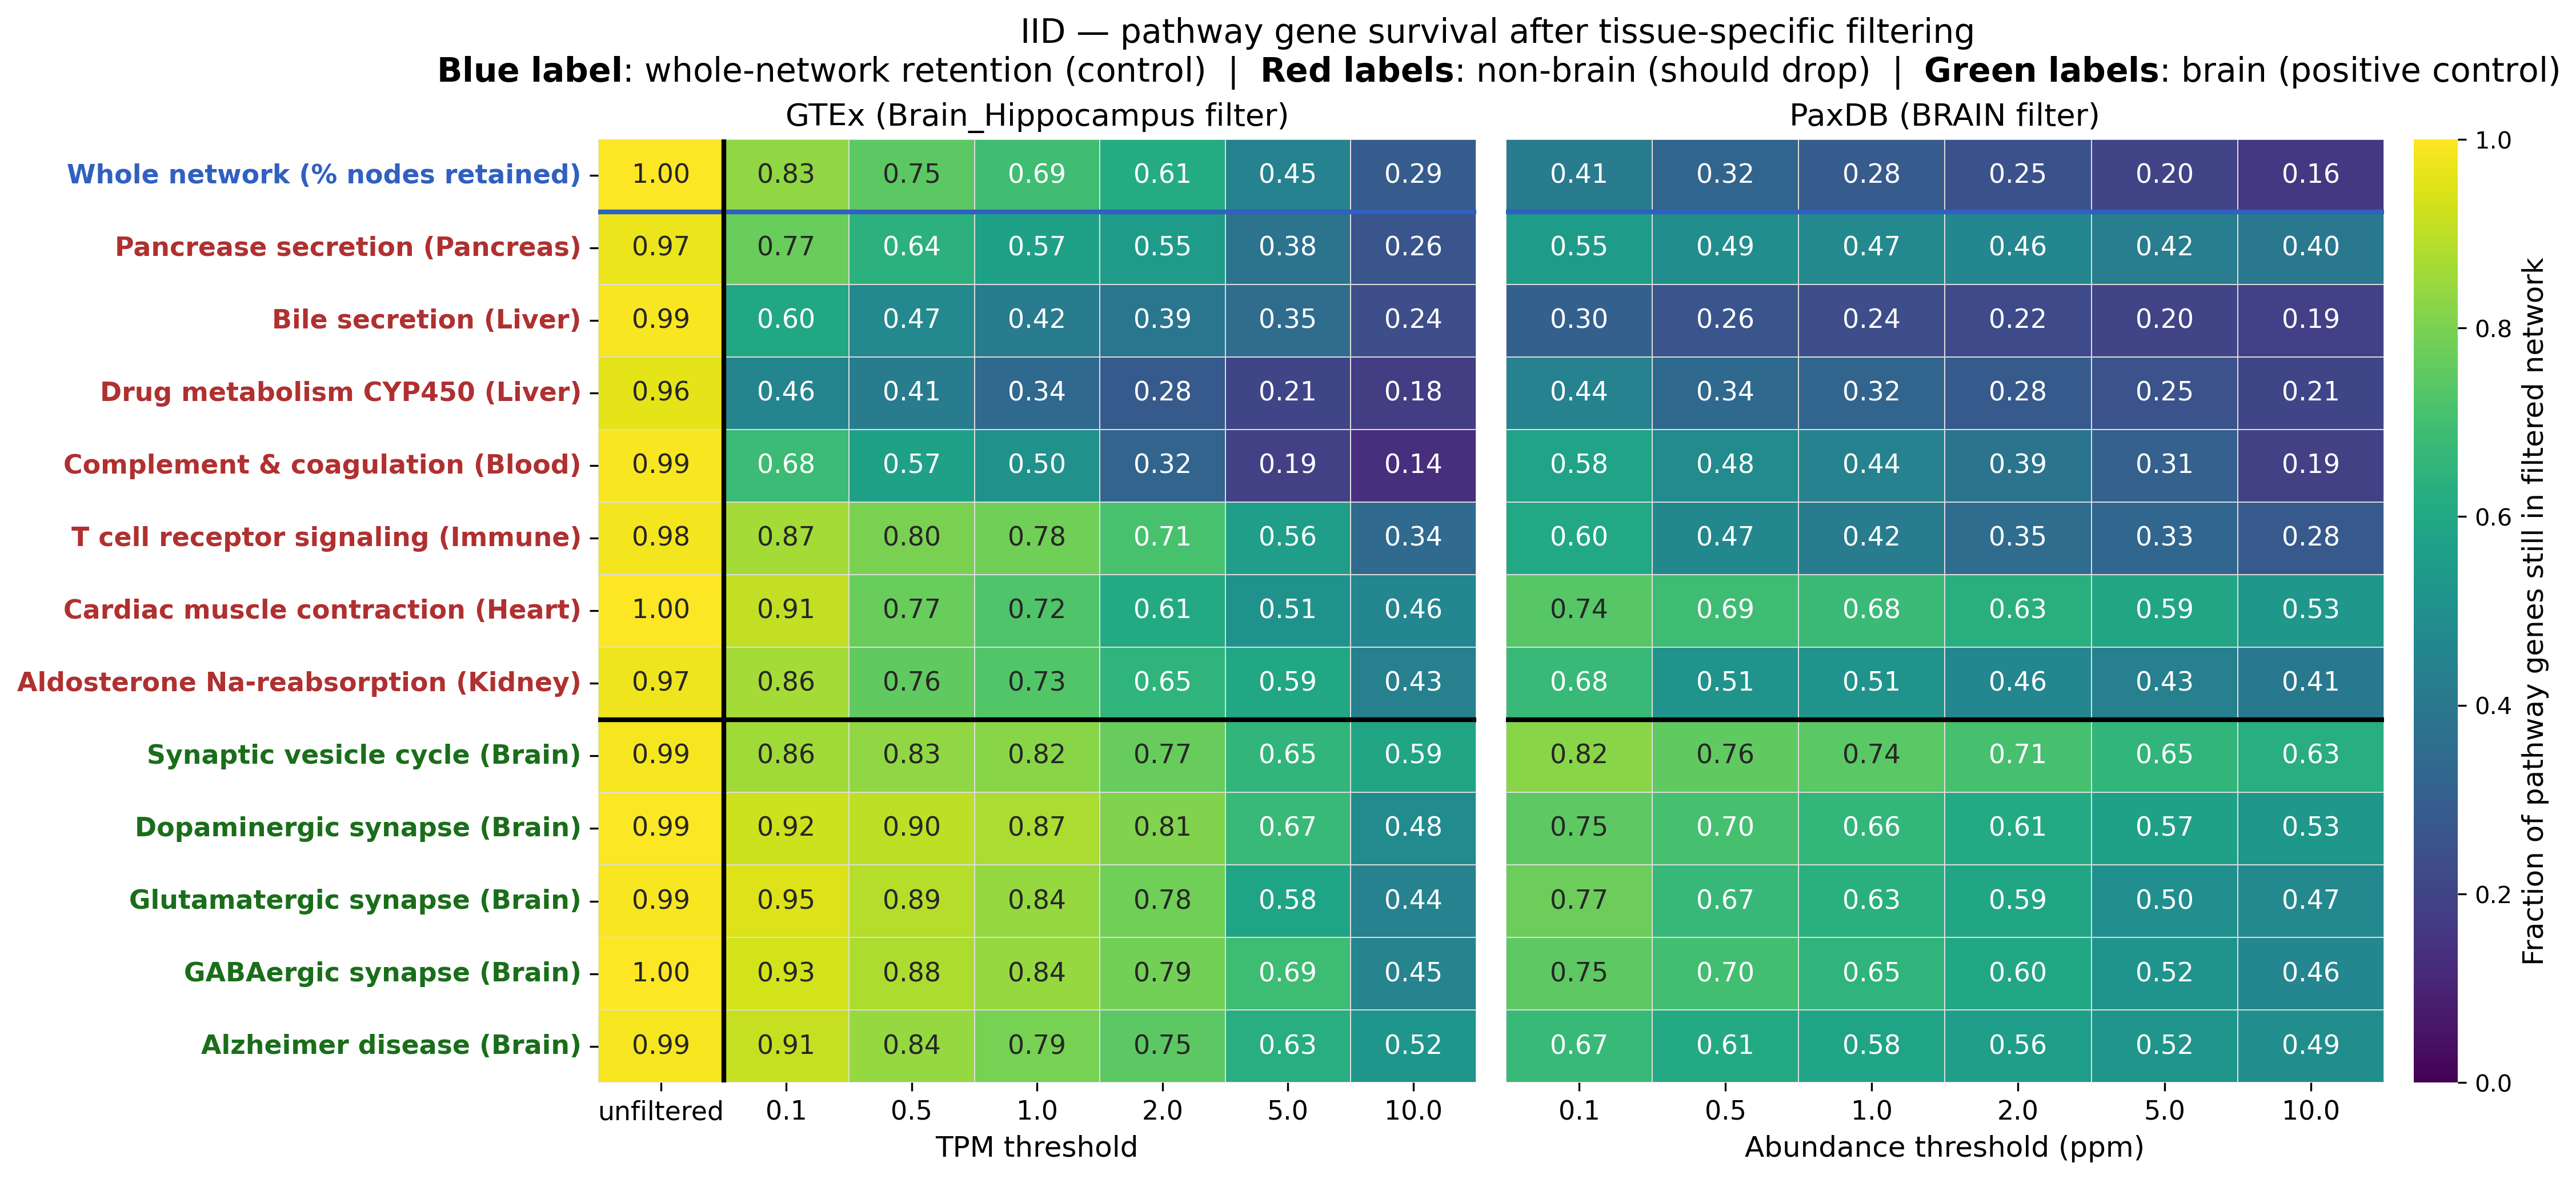

/var/folders/c3/7nxlprcs7lz9sl8c6_mdhy2w0000gn/T/ipykernel_89079/1794678940.py:30: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.94])


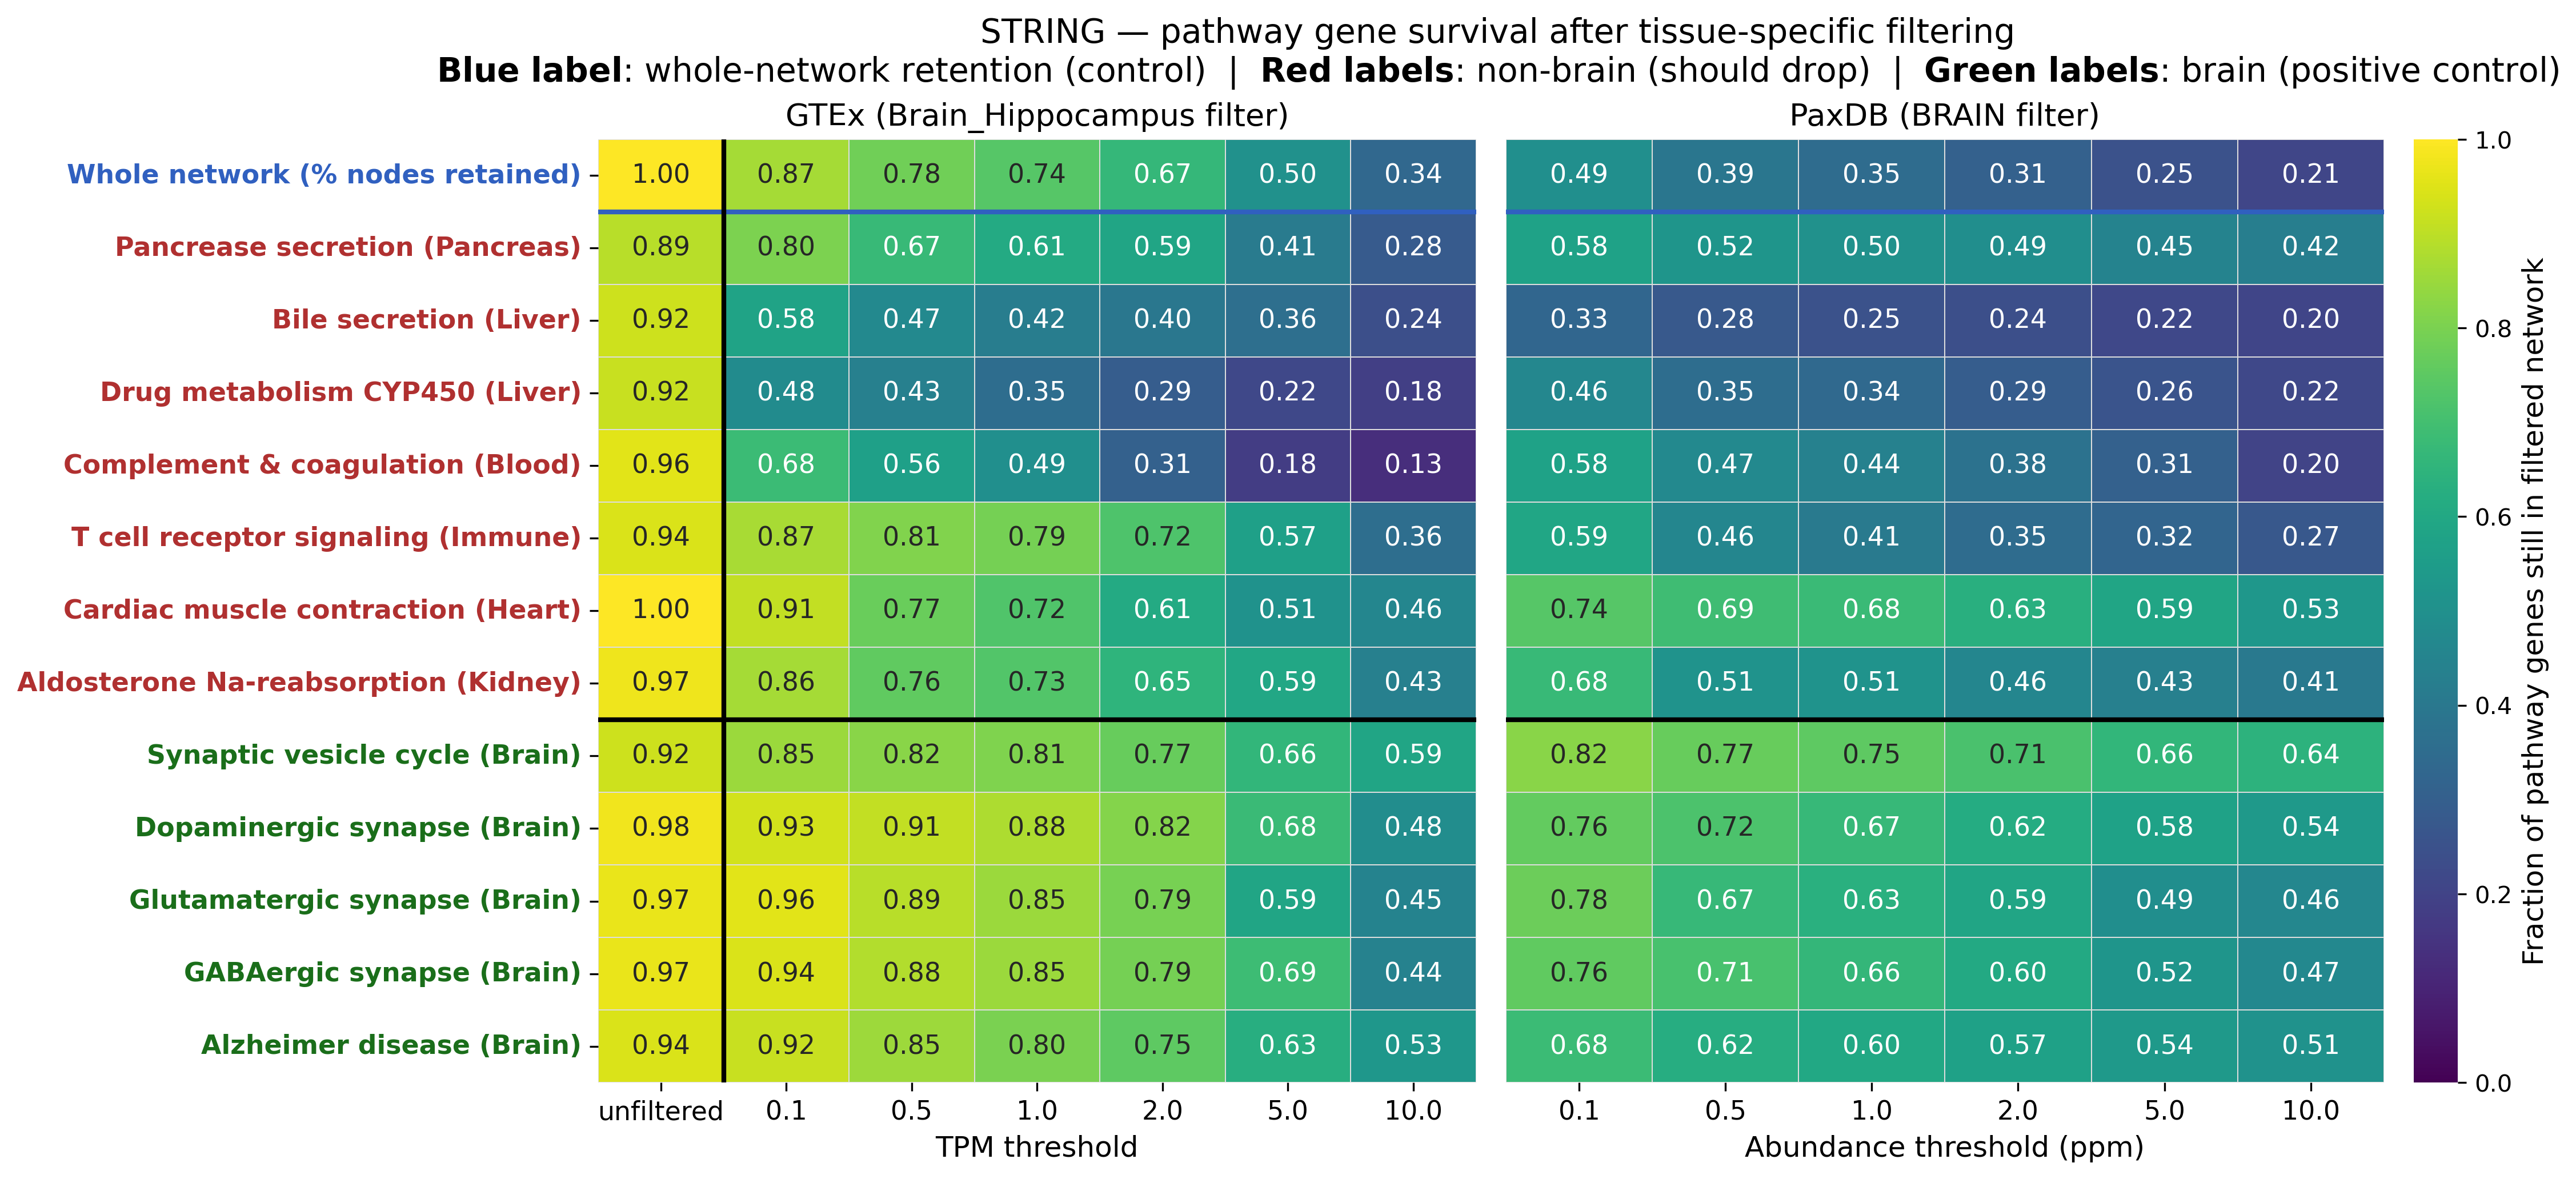

In [15]:
# Combined GTEx + PaxDb panels (per network), sharing one colorbar so the two
# filtering sources are directly comparable side by side rather than as two
# separate figures with their own independently-scaled color legends.
for net_name in NETWORKS:
    n_rows = 1 + len(NON_BRAIN) + len(BRAIN)
    fig, (ax_gtex, ax_paxdb, cax) = plt.subplots(
        1, 3, figsize=(14, max(5, n_rows * 0.55)), dpi=300,
        gridspec_kw={"width_ratios": [1, 1, 0.05], "wspace": 0.05},
    )

    pathway_survival_heatmap(
        survival_df, net_name, node_sets, original_nodes,
        ax=ax_gtex, cbar=False,
        title="GTEx (Brain_Hippocampus filter)", xlabel="TPM threshold",
    )
    pathway_survival_heatmap(
        paxdb_survival_df, net_name, paxdb_node_sets, original_nodes,
        ax=ax_paxdb, cbar=True, cbar_ax=cax, yticklabels=False,
        title="PaxDB (BRAIN filter)", xlabel="Abundance threshold (ppm)",
        show_unfiltered=False,
    )

    fig.suptitle(
        f"{net_name.upper()} — pathway gene survival after tissue-specific filtering\n"
        r"$\bf{Blue\ label}$: whole-network retention (control)  |  "
        r"$\bf{Red\ labels}$: non-brain (should drop)  |  "
        r"$\bf{Green\ labels}$: brain (positive control)",
        fontsize=14,
    )
    plt.tight_layout(rect=[0, 0, 1, 0.94])
    plt.savefig(OUT_ROOT / f"pathway_survival_{net_name}_gtex_paxdb.png", dpi=150, bbox_inches="tight")
    plt.show()

## 9 — TCGA GBM (Glioblastoma): Cancer & Glioma Pathway Survival Across Thresholds

Same analysis as Sections 7–8, but using TCGA-GBM (Glioblastoma Multiforme) bulk tumor RNA-seq median TPM as the filtering context instead of normal-tissue GTEx/PaxDB data. Uses the pipeline script's native `--filtering_source TCGA` with `--context TCGA_GBM`.

Since the filtering context is now tumor tissue rather than healthy brain, the interesting comparison is not just "brain vs. non-brain" but:
- **Glioma-specific pathway** (KEGG `hsa05214`, the disease pathway for glioblastoma: EGFR/PDGFRA/PI3K-AKT/TP53/RB1 signaling) — expect strong retention.
- **General cancer pathways** (cell cycle, p53, PI3K-Akt, MAPK, "Pathways in cancer") — expect retention, since these are broadly active in proliferating tumor tissue.
- **Brain/neuronal pathways** (the same synaptic + Alzheimer pathways used in Sections 7–8 as the healthy-brain positive control) — retention may be *lower* here than under GTEx/PaxDB brain filtering, since GBM tumor tissue is glial/proliferative rather than normal neuronal tissue.
- **Other-tissue pathways** (Liver, Pancreas, Heart, Blood, Kidney) — still expected to drop out, as a sanity control.

In [16]:
TCGA_CONTEXT     = "TCGA_GBM"
TCGA_THRESHOLDS  = [0.1, 0.5, 1.0, 2.0, 5.0, 10.0]  # median TPM (tumor)
TCGA_OUT_ROOT    = OUT_ROOT / "tcga_gbm"
TCGA_OUT_ROOT.mkdir(exist_ok=True)

print("TCGA context:", TCGA_CONTEXT)
print("TCGA thresholds (TPM):", TCGA_THRESHOLDS)

TCGA context: TCGA_GBM
TCGA thresholds (TPM): [0.1, 0.5, 1.0, 2.0, 5.0, 10.0]


In [17]:
tcga_filtering_file = resolve_filtering_file("TCGA", TCGA_CONTEXT)

tcga_run_index = {}  # (net_name, threshold) -> output_dir

for net_name, net_path in NETWORKS.items():
    for thr in TCGA_THRESHOLDS:
        tag    = f"thr_{str(thr).replace('.', '_')}"
        outdir = TCGA_OUT_ROOT / net_name / tag
        outdir.mkdir(parents=True, exist_ok=True)

        filtered_gt = outdir / f"{net_path.stem}.{TCGA_CONTEXT}.TCGA.{thr}.gt"
        if filtered_gt.exists():
            print(f"[skip] {net_name} thr={thr}  (already exists)")
            tcga_run_index[(net_name, thr)] = outdir
            continue

        cmd = [
            sys.executable, str(SCRIPT),
            "--network",                str(net_path),
            "--context",                TCGA_CONTEXT,
            "--threshold",              str(thr),
            "--filtering_source",       "TCGA",
            "--custom_expression_file", "null",
            "--filtering_file",        str(tcga_filtering_file),
            "--id_space",               "symbol",
        ]
        result = subprocess.run(cmd, cwd=str(outdir), env=env,
                                capture_output=True, text=True)
        if result.returncode != 0:
            print(f"ERROR {net_name} thr={thr}:\n{result.stderr[-2000:]}")
        else:
            print(f"[done] {net_name} thr={thr}")
        tcga_run_index[(net_name, thr)] = outdir

print("All TCGA GBM runs complete.")

[skip] iid thr=0.1  (already exists)
[skip] iid thr=0.5  (already exists)
[skip] iid thr=1.0  (already exists)
[skip] iid thr=2.0  (already exists)
[skip] iid thr=5.0  (already exists)
[skip] iid thr=10.0  (already exists)
[skip] string thr=0.1  (already exists)
[skip] string thr=0.5  (already exists)
[skip] string thr=1.0  (already exists)
[skip] string thr=2.0  (already exists)
[skip] string thr=5.0  (already exists)
[skip] string thr=10.0  (already exists)
All TCGA GBM runs complete.


In [18]:
tcga_node_sets = {}  # (net_name, thr) -> {"retained": set, "removed": set}
for (net_name, thr), outdir in tcga_run_index.items():
    net_path    = NETWORKS[net_name]
    filtered_gt = outdir / f"{net_path.stem}.{TCGA_CONTEXT}.TCGA.{thr}.gt"
    retained    = node_names(filtered_gt)
    removed     = original_nodes[net_name] - retained
    tcga_node_sets[(net_name, thr)] = {"retained": retained, "removed": removed}

print("Node sets collected for", len(tcga_node_sets), "TCGA GBM runs.")

Node sets collected for 12 TCGA GBM runs.


In [19]:
# Additional KEGG pathways for the TCGA GBM comparison, on top of the
# NON_BRAIN / BRAIN pathways already fetched in Section 7.
CANCER_PATHWAYS = {
    "Pathways in cancer (Cancer)":         "hsa05200",
    "Cell cycle (Cancer)":                 "hsa04110",
    "p53 signaling pathway (Cancer)":      "hsa04115",
    "PI3K-Akt signaling pathway (Cancer)": "hsa04151",
    "MAPK signaling pathway (Cancer)":     "hsa04010",
}
GLIOMA_PATHWAYS = {
    "Glioma (Glioblastoma)": "hsa05214",
}
NEW_PATHWAYS = {**CANCER_PATHWAYS, **GLIOMA_PATHWAYS}

for name, pid in NEW_PATHWAYS.items():
    if name not in pathway_genes:
        genes = fetch_kegg_genes(pid)
        pathway_genes[name] = genes
        print(f"  {pid}  {name}: {len(genes)} genes")
    else:
        print(f"  {name}: {len(pathway_genes[name])} genes (cached)")

with open(CACHE_FILE, "w") as f:
    json.dump(pathway_genes, f, indent=2)

TCGA_PATHWAYS = {**PATHWAYS, **NEW_PATHWAYS}
CANCER = list(CANCER_PATHWAYS.keys())
GLIOMA = list(GLIOMA_PATHWAYS.keys())

  Pathways in cancer (Cancer): 533 genes (cached)
  Cell cycle (Cancer): 158 genes (cached)
  p53 signaling pathway (Cancer): 75 genes (cached)
  PI3K-Akt signaling pathway (Cancer): 361 genes (cached)
  MAPK signaling pathway (Cancer): 301 genes (cached)
  Glioma (Glioblastoma): 76 genes (cached)


In [20]:
tcga_rows = []
for net_name in NETWORKS:
    for pathway_name in TCGA_PATHWAYS:
        gene_set   = set(pathway_genes[pathway_name])
        in_network = gene_set & original_nodes[net_name]
        if not in_network:
            continue
        tcga_rows.append({
            "network":  net_name,
            "pathway":  pathway_name,
            "threshold": "unfiltered",
            "n_in_network": len(in_network),
            "n_surviving":  len(in_network),
            "frac_surviving": len(in_network) / len(gene_set),
        })
        for thr in TCGA_THRESHOLDS:
            retained    = tcga_node_sets[(net_name, thr)]["retained"]
            n_surviving = len(in_network & retained)
            tcga_rows.append({
                "network":  net_name,
                "pathway":  pathway_name,
                "threshold": thr,
                "n_in_network": len(in_network),
                "n_surviving":  n_surviving,
                "frac_surviving": n_surviving / len(in_network),
            })

tcga_survival_df = pd.DataFrame(tcga_rows)
print(tcga_survival_df.groupby(["network", "pathway"])[["n_in_network"]].first().to_string())

                                              n_in_network
network pathway                                           
iid     Aldosterone Na-reabsorption (Kidney)            37
        Alzheimer disease (Brain)                      383
        Bile secretion (Liver)                          89
        Cardiac muscle contraction (Heart)              87
        Cell cycle (Cancer)                            156
        Complement & coagulation (Blood)                88
        Dopaminergic synapse (Brain)                   132
        Drug metabolism CYP450 (Liver)                  68
        GABAergic synapse (Brain)                       89
        Glioma (Glioblastoma)                           75
        Glutamatergic synapse (Brain)                  115
        MAPK signaling pathway (Cancer)                300
        PI3K-Akt signaling pathway (Cancer)            358
        Pancrease secretion (Pancreas)                 100
        Pathways in cancer (Cancer)                    5

In [21]:
def pathway_survival_heatmap_4group(df, net_name, node_sets, original_nodes, outfile=None,
                                     filter_label="TCGA TCGA_GBM filter", xlabel="TPM threshold (TCGA GBM)",
                                     groups=None, ax=None, cbar=True, cbar_ax=None,
                                     yticklabels=True, title=None, show_unfiltered=True):
    """Like pathway_survival_heatmap, but with labeled row groups instead of
    two: by default all four (other-tissue control, brain/neuronal
    positive control from Sections 7-8, cancer general, and glioma
    GBM-specific positive control). Pass `groups` to restrict/reorder which
    of these are drawn, e.g. brain vs. cancer/glioma only.

    Pass `ax` (and optionally `cbar_ax`) to draw into an existing figure/panel
    instead of creating a standalone one — used to combine this TCGA panel
    with the GTEx Brain_Hippocampus panel from Section 7 into a single figure
    with one shared colorbar."""
    pivot = df[df["network"] == net_name].pivot(
        index="pathway", columns="threshold", values="frac_surviving"
    )
    numeric_thresholds = sorted(c for c in pivot.columns if c != "unfiltered")
    col_order = (["unfiltered"] if show_unfiltered and "unfiltered" in pivot.columns else []) + numeric_thresholds
    pivot = pivot[col_order]

    if groups is None:
        groups = [
            (NON_BRAIN, "#b03030", "Red",    "other tissues (should drop)"),
            (BRAIN,     "#1a6e1a", "Green",  "brain/neuronal (healthy-brain control)"),
            (CANCER,    "#c98a1f", "Orange", "cancer (general)"),
            (GLIOMA,    "#7a1fc9", "Purple", "glioma (GBM-specific)"),
        ]
    ordered, label_colors, group_bounds = [], {}, []
    for names, color, _, _ in groups:
        present = [p for p in names if p in pivot.index]
        ordered.extend(present)
        group_bounds.append(len(ordered))
        for p in present:
            label_colors[p] = color
    pivot = pivot.reindex(ordered)

    # Whole-network retention control row, as in Sections 7-8.
    control_label = "Whole network (% nodes retained)"
    n_all_nodes = len(original_nodes[net_name])
    control_row = {"unfiltered": 1.0}
    for thr in numeric_thresholds:
        control_row[thr] = len(node_sets[(net_name, thr)]["retained"]) / n_all_nodes
    control_row = pd.Series(control_row)[col_order]
    pivot   = pd.concat([control_row.to_frame(control_label).T, pivot])
    ordered = [control_label] + ordered
    group_bounds = [b + 1 for b in group_bounds]  # shift for the control row

    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(9, max(5, len(ordered) * 0.55)), dpi=200)
    sns.heatmap(
        pivot, ax=ax,
        annot=True, fmt=".2f", annot_kws={"fontsize": 11},
        cmap="viridis", vmin=0, vmax=1,
        linewidths=0.4, linecolor="#dddddd",
        cbar=cbar, cbar_ax=cbar_ax,
        cbar_kws={"label": "Fraction of pathway genes still in filtered network"} if cbar else {},
        yticklabels=yticklabels,
    )
    ax.tick_params(axis="x", labelsize=11)
    if cbar:
        cbar_obj = ax.collections[0].colorbar
        cbar_obj.ax.yaxis.label.set_size(12)
        cbar_obj.ax.tick_params(labelsize=10)
    ax.axhline(1, color="#3060c0", lw=2)               # separates control row from pathways
    for bound in group_bounds[:-1]:
        ax.axhline(bound, color="black", lw=2)          # separates the pathway groups
    if "unfiltered" in col_order:
        ax.axvline(1, color="black", lw=2)

    if yticklabels:
        for tick, label in zip(ax.get_yticklabels(), ordered):
            tick.set_color("#3060c0" if label == control_label else label_colors.get(label, "black"))
            tick.set_fontweight("bold")
            tick.set_fontsize(11)

    if title is None:
        legend = "  |  ".join(
            rf"$\bf{{{color_name}}}$: {label}" for _, _, color_name, label in groups
        )
        title = (f"{net_name.upper()} — pathway gene survival after {filter_label}\n"
                 r"$\bf{Blue}$: whole-network retention (control)  |  " + legend)
    ax.set_title(title, fontsize=13)
    ax.set_xlabel(f"{xlabel}", fontsize=12)
    ax.set_ylabel("")

    if standalone:
        plt.tight_layout()
        if outfile:
            plt.savefig(outfile, dpi=150, bbox_inches="tight")
        plt.show()
    return ax


In [22]:
# Extend the GTEx (Brain_Hippocampus) survival data to the same pathway set
# used for the TCGA comparison (brain + cancer + glioma), so the two panels
# below compare identical rows rather than GTEx's narrower non-brain/brain
# set against TCGA's brain/cancer/glioma set.
gtex_ext_rows = []
for net_name in NETWORKS:
    for pathway_name in TCGA_PATHWAYS:
        gene_set   = set(pathway_genes[pathway_name])
        in_network = gene_set & original_nodes[net_name]
        if not in_network:
            continue
        gtex_ext_rows.append({
            "network":  net_name,
            "pathway":  pathway_name,
            "threshold": "unfiltered",
            "n_in_network": len(in_network),
            "n_surviving":  len(in_network),
            "frac_surviving": len(in_network) / len(gene_set),
        })
        for thr in THRESHOLDS:
            retained    = node_sets[(net_name, thr)]["retained"]
            n_surviving = len(in_network & retained)
            gtex_ext_rows.append({
                "network":  net_name,
                "pathway":  pathway_name,
                "threshold": thr,
                "n_in_network": len(in_network),
                "n_surviving":  n_surviving,
                "frac_surviving": n_surviving / len(in_network),
            })

gtex_survival_df_ext = pd.DataFrame(gtex_ext_rows)
print(gtex_survival_df_ext.groupby(["network", "pathway"])[["n_in_network"]].first().to_string())


                                              n_in_network
network pathway                                           
iid     Aldosterone Na-reabsorption (Kidney)            37
        Alzheimer disease (Brain)                      383
        Bile secretion (Liver)                          89
        Cardiac muscle contraction (Heart)              87
        Cell cycle (Cancer)                            156
        Complement & coagulation (Blood)                88
        Dopaminergic synapse (Brain)                   132
        Drug metabolism CYP450 (Liver)                  68
        GABAergic synapse (Brain)                       89
        Glioma (Glioblastoma)                           75
        Glutamatergic synapse (Brain)                  115
        MAPK signaling pathway (Cancer)                300
        PI3K-Akt signaling pathway (Cancer)            358
        Pancrease secretion (Pancreas)                 100
        Pathways in cancer (Cancer)                    5

/var/folders/c3/7nxlprcs7lz9sl8c6_mdhy2w0000gn/T/ipykernel_89079/2566866053.py:48: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.94])


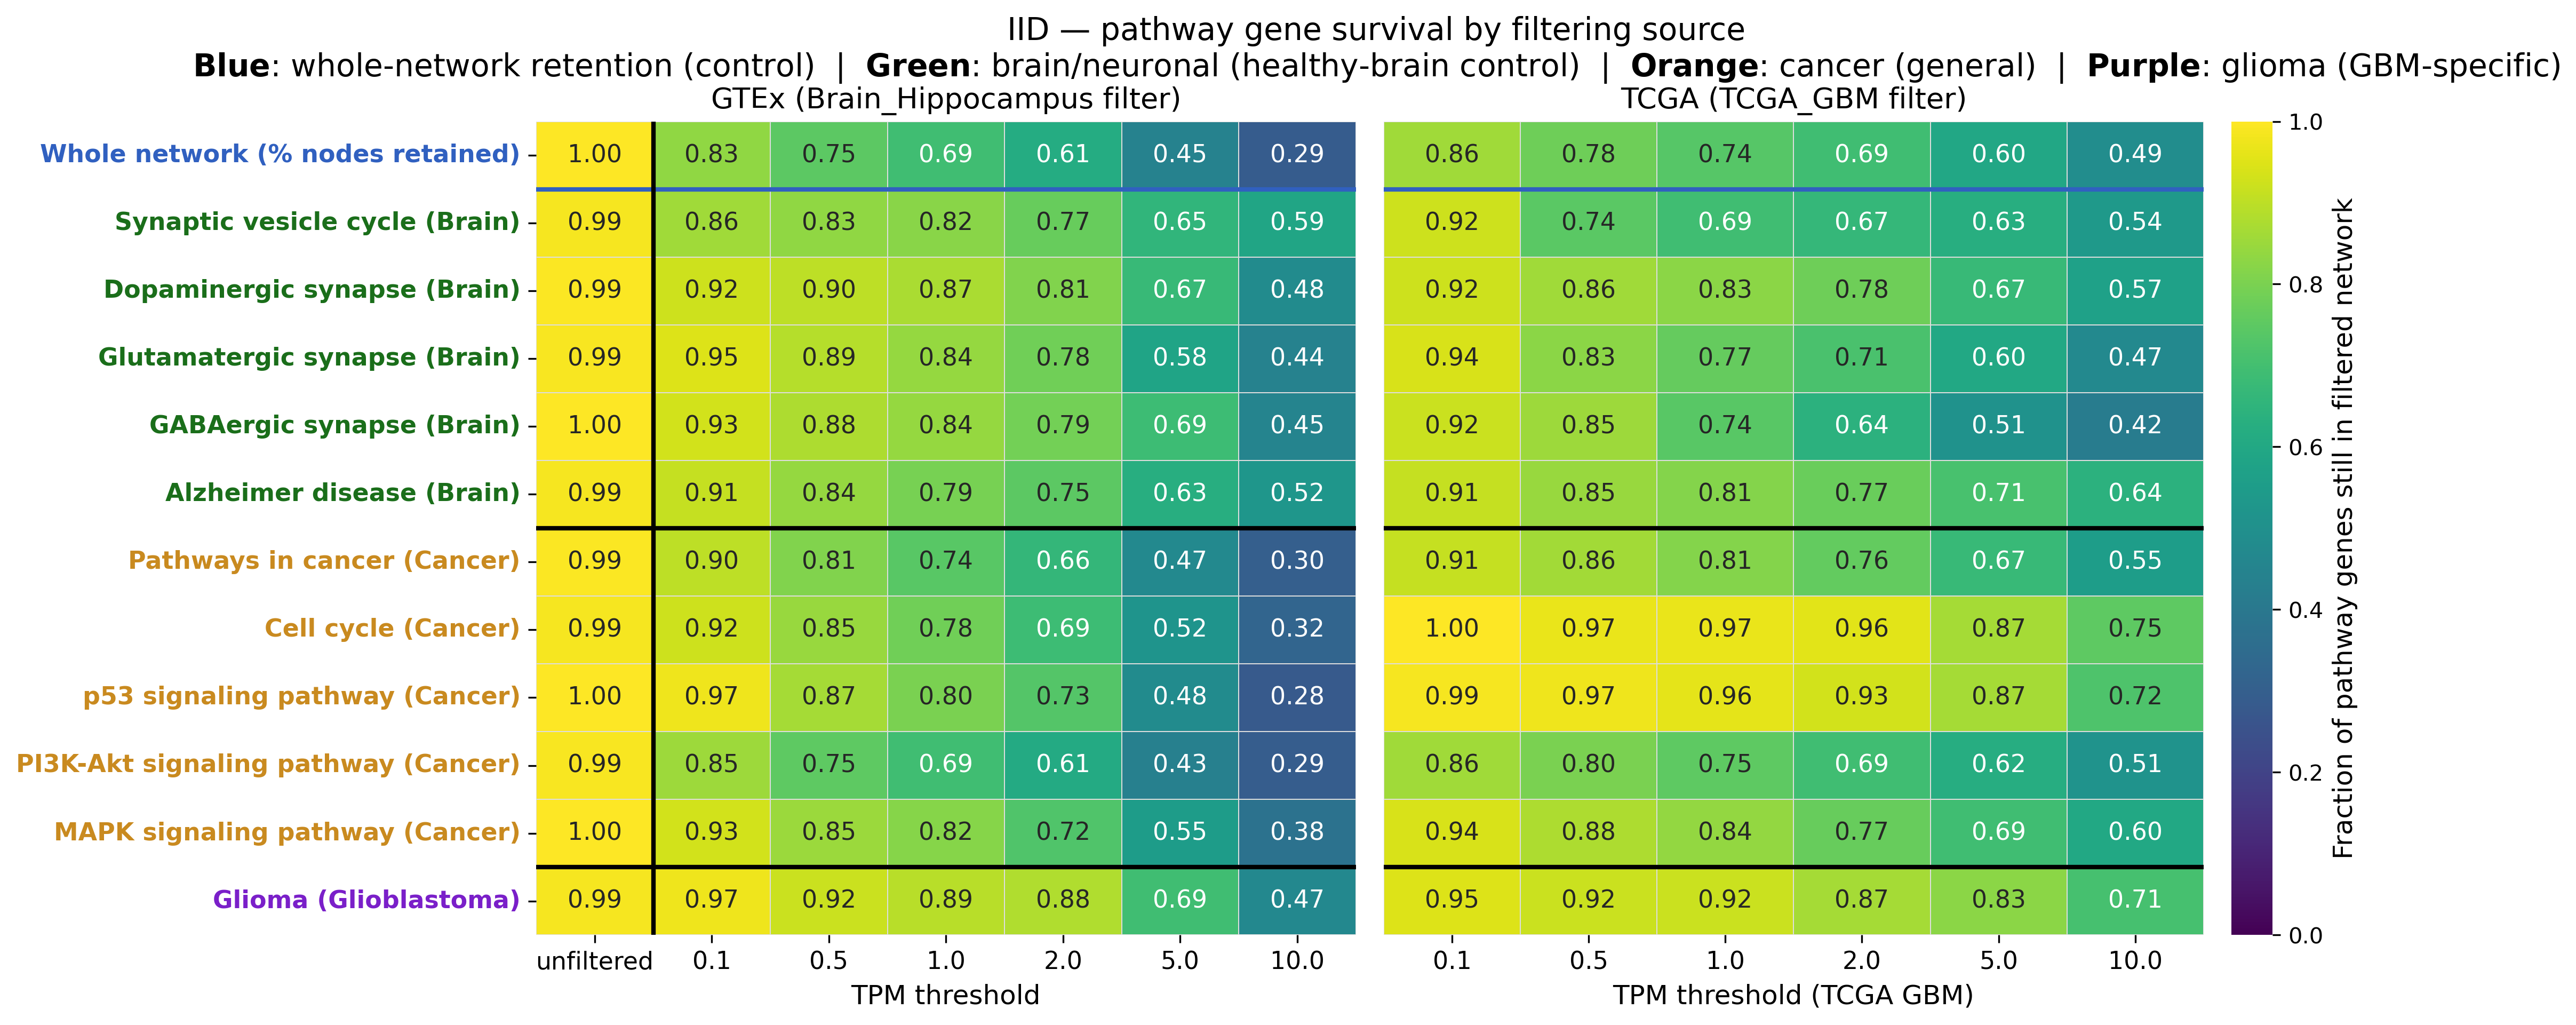

/var/folders/c3/7nxlprcs7lz9sl8c6_mdhy2w0000gn/T/ipykernel_89079/2566866053.py:48: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.94])


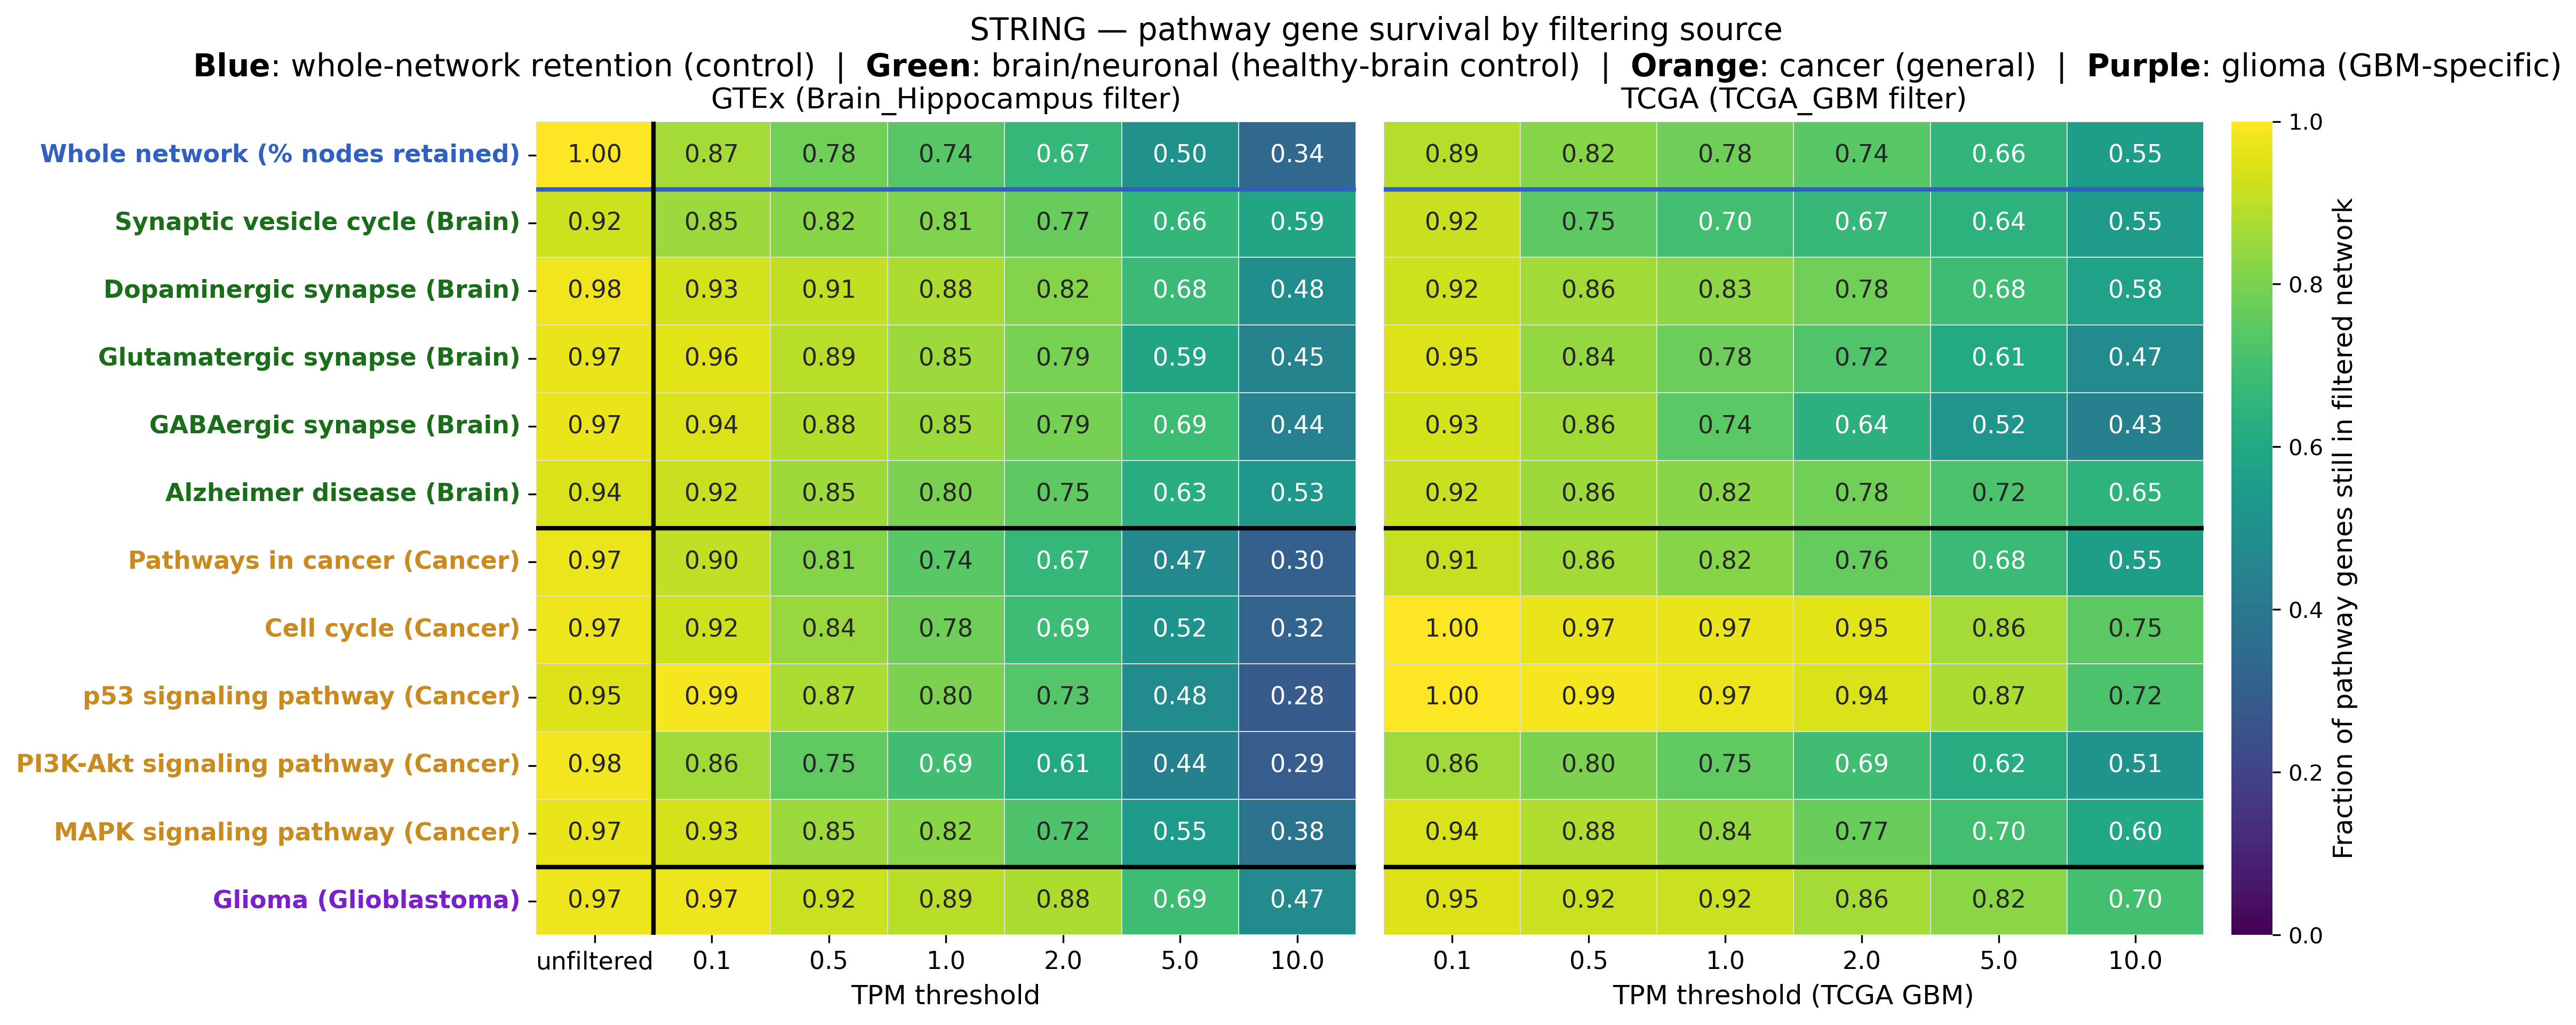

In [23]:
# Combined GTEx Brain_Hippocampus + TCGA GBM panels (per network), sharing one
# colorbar — same style as the GTEx/PaxDb merge in Section 8, now comparing
# the healthy-brain filter against the GBM-tumor filter side by side. Both
# panels use the same brain/cancer/glioma pathway set (gtex_survival_df_ext
# above extends GTEx's survival data to cover it too), so the rows line up
# for a direct comparison; the other-tissue control group from Sections 7-8
# is dropped as it isn't the comparison of interest for GBM. Since both
# panels share the same color legend, it's shown once as a figure-level
# suptitle instead of in each panel's title (repeating it per-panel is what
# caused the two titles to collide in the middle of the figure).
CANCER_BRAIN_GROUPS = [
    (BRAIN,  "#1a6e1a", "Green",  "brain/neuronal (healthy-brain control)"),
    (CANCER, "#c98a1f", "Orange", "cancer (general)"),
    (GLIOMA, "#7a1fc9", "Purple", "glioma (GBM-specific)"),
]
legend = "  |  ".join(
    rf"$\bf{{{color_name}}}$: {label}" for _, _, color_name, label in CANCER_BRAIN_GROUPS
)

for net_name in NETWORKS:
    n_rows = 1 + len(BRAIN) + len(CANCER) + len(GLIOMA)
    fig, (ax_gtex, ax_tcga, cax) = plt.subplots(
        1, 3, figsize=(14, max(5, n_rows * 0.55)), dpi=300,
        gridspec_kw={"width_ratios": [1, 1, 0.05], "wspace": 0.05},
    )

    pathway_survival_heatmap_4group(
        gtex_survival_df_ext, net_name, node_sets, original_nodes,
        ax=ax_gtex, cbar=False,
        groups=CANCER_BRAIN_GROUPS,
        filter_label="Brain_Hippocampus filter", xlabel="TPM threshold",
        title="GTEx (Brain_Hippocampus filter)",
    )
    pathway_survival_heatmap_4group(
        tcga_survival_df, net_name, tcga_node_sets, original_nodes,
        ax=ax_tcga, cbar=True, cbar_ax=cax, yticklabels=False,
        groups=CANCER_BRAIN_GROUPS,
        filter_label=f"{TCGA_CONTEXT} filter", xlabel="TPM threshold (TCGA GBM)",
        title=f"TCGA ({TCGA_CONTEXT} filter)",
        show_unfiltered=False,
    )

    fig.suptitle(
        f"{net_name.upper()} — pathway gene survival by filtering source\n"
        r"$\bf{Blue}$: whole-network retention (control)  |  " + legend,
        fontsize=14,
    )
    plt.tight_layout(rect=[0, 0, 1, 0.94])
    plt.savefig(OUT_ROOT / f"pathway_survival_{net_name}_gtex_tcga_gbm.png", dpi=300, bbox_inches="tight")
    plt.show()


## 10 — Downstream Disease-Module Jaccard Similarity

Module overlap (Jaccard similarity, seeds excluded) across pipeline runs, from the pipeline's own MultiQC evaluation output. Hierarchically clustered for readability.

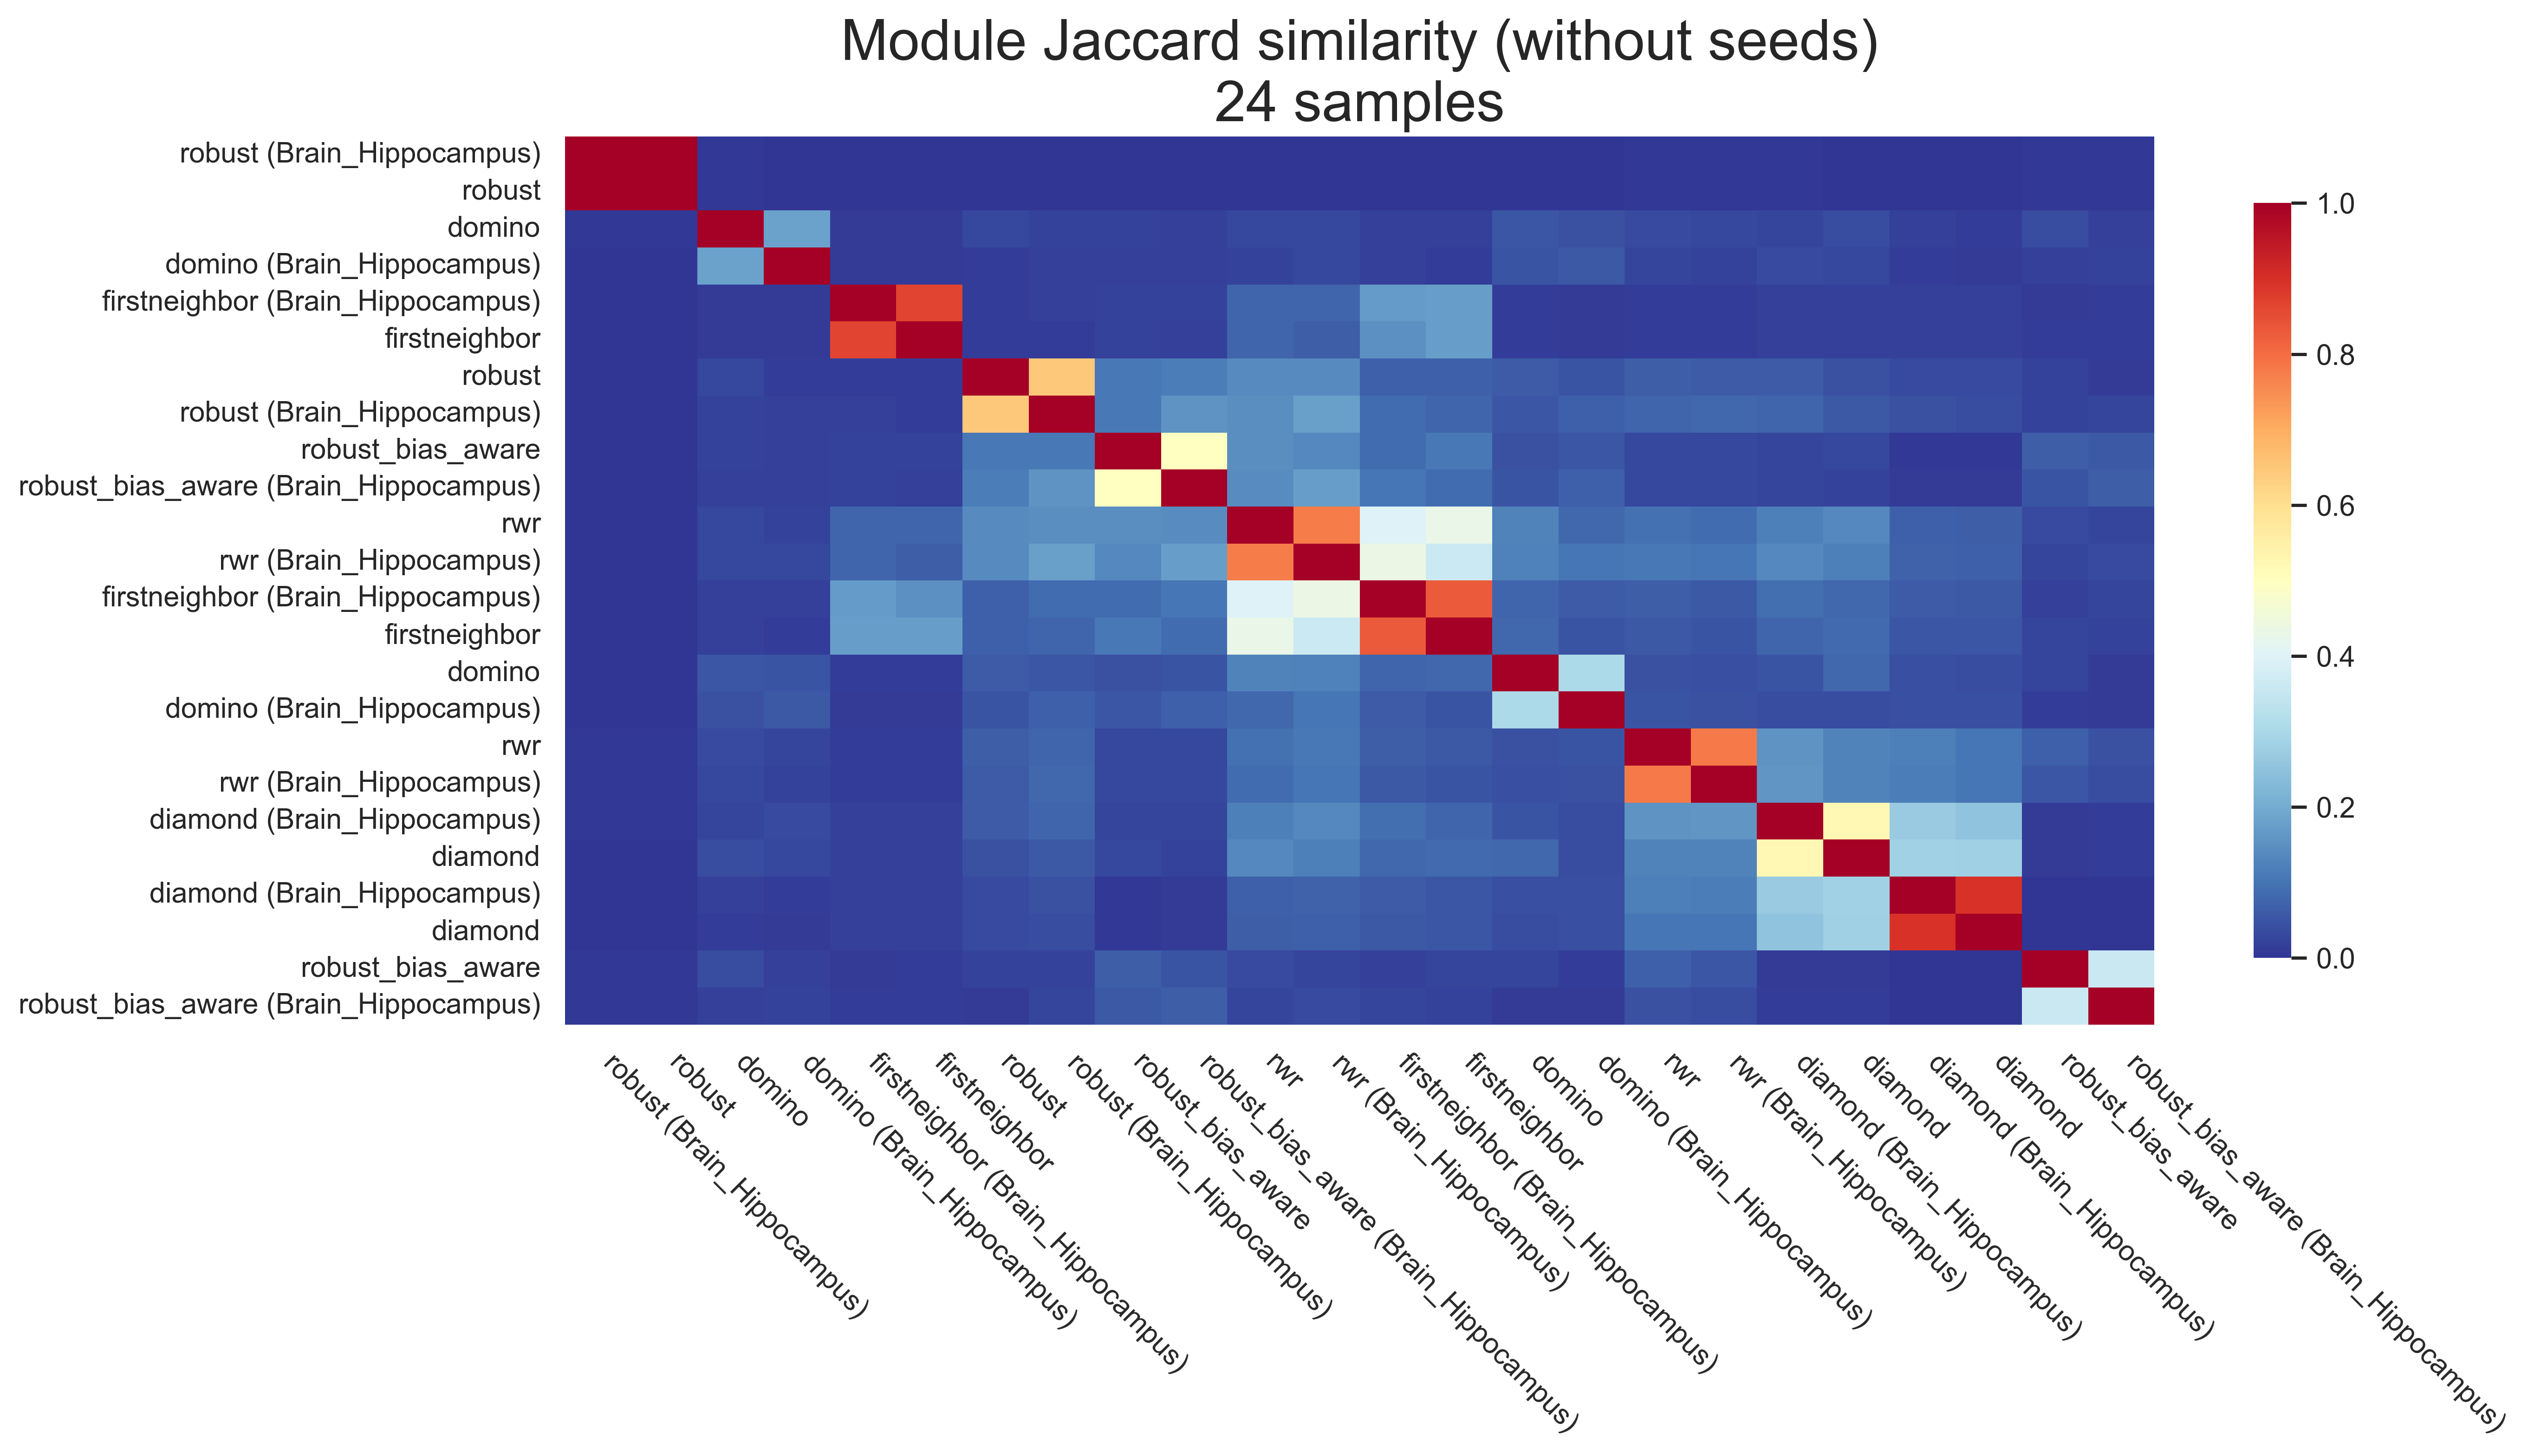

In [24]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform

similarity_path = "data/jaccard_similarity_no_seeds_matrix_mqc.tsv"
similarity_df = pd.read_csv(similarity_path, sep="\t", index_col=0)

def simplify_sample_name(sample_name: str) -> str:
    parts = sample_name.split(".")
    tool = parts[-1]
    tissue = parts[-2] if len(parts) > 1 and "_" in parts[-2] else None
    return f"{tool} ({tissue})" if tissue else tool

labels = [simplify_sample_name(name) for name in similarity_df.index]
similarity_df.index = labels
similarity_df.columns = labels

# Cluster samples using hierarchical clustering on 1 - similarity.
distance_df = 1 - similarity_df
distance_df = (distance_df + distance_df.T) / 2
for idx in range(len(distance_df)):
    distance_df.iat[idx, idx] = 0.0

linkage_matrix = linkage(squareform(distance_df.to_numpy()), method="average", optimal_ordering=True)
cluster_order = leaves_list(linkage_matrix)
clustered_df = similarity_df.iloc[cluster_order, cluster_order]


sns.set_theme(style="white")
fig, ax = plt.subplots(figsize=(14, 8), dpi = 400, facecolor="white")
ax.set_facecolor("white")
sns.heatmap(clustered_df, cmap="RdYlBu_r", vmin=0, vmax=1, ax=ax, cbar_kws={"shrink": 0.85})
ax.set_title(f"Module Jaccard similarity (without seeds)\n{clustered_df.shape[0]} samples", fontsize=22)
ax.set_xticklabels(ax.get_xticklabels(), rotation=-45, ha="left")
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
plt.tight_layout()
plt.show()


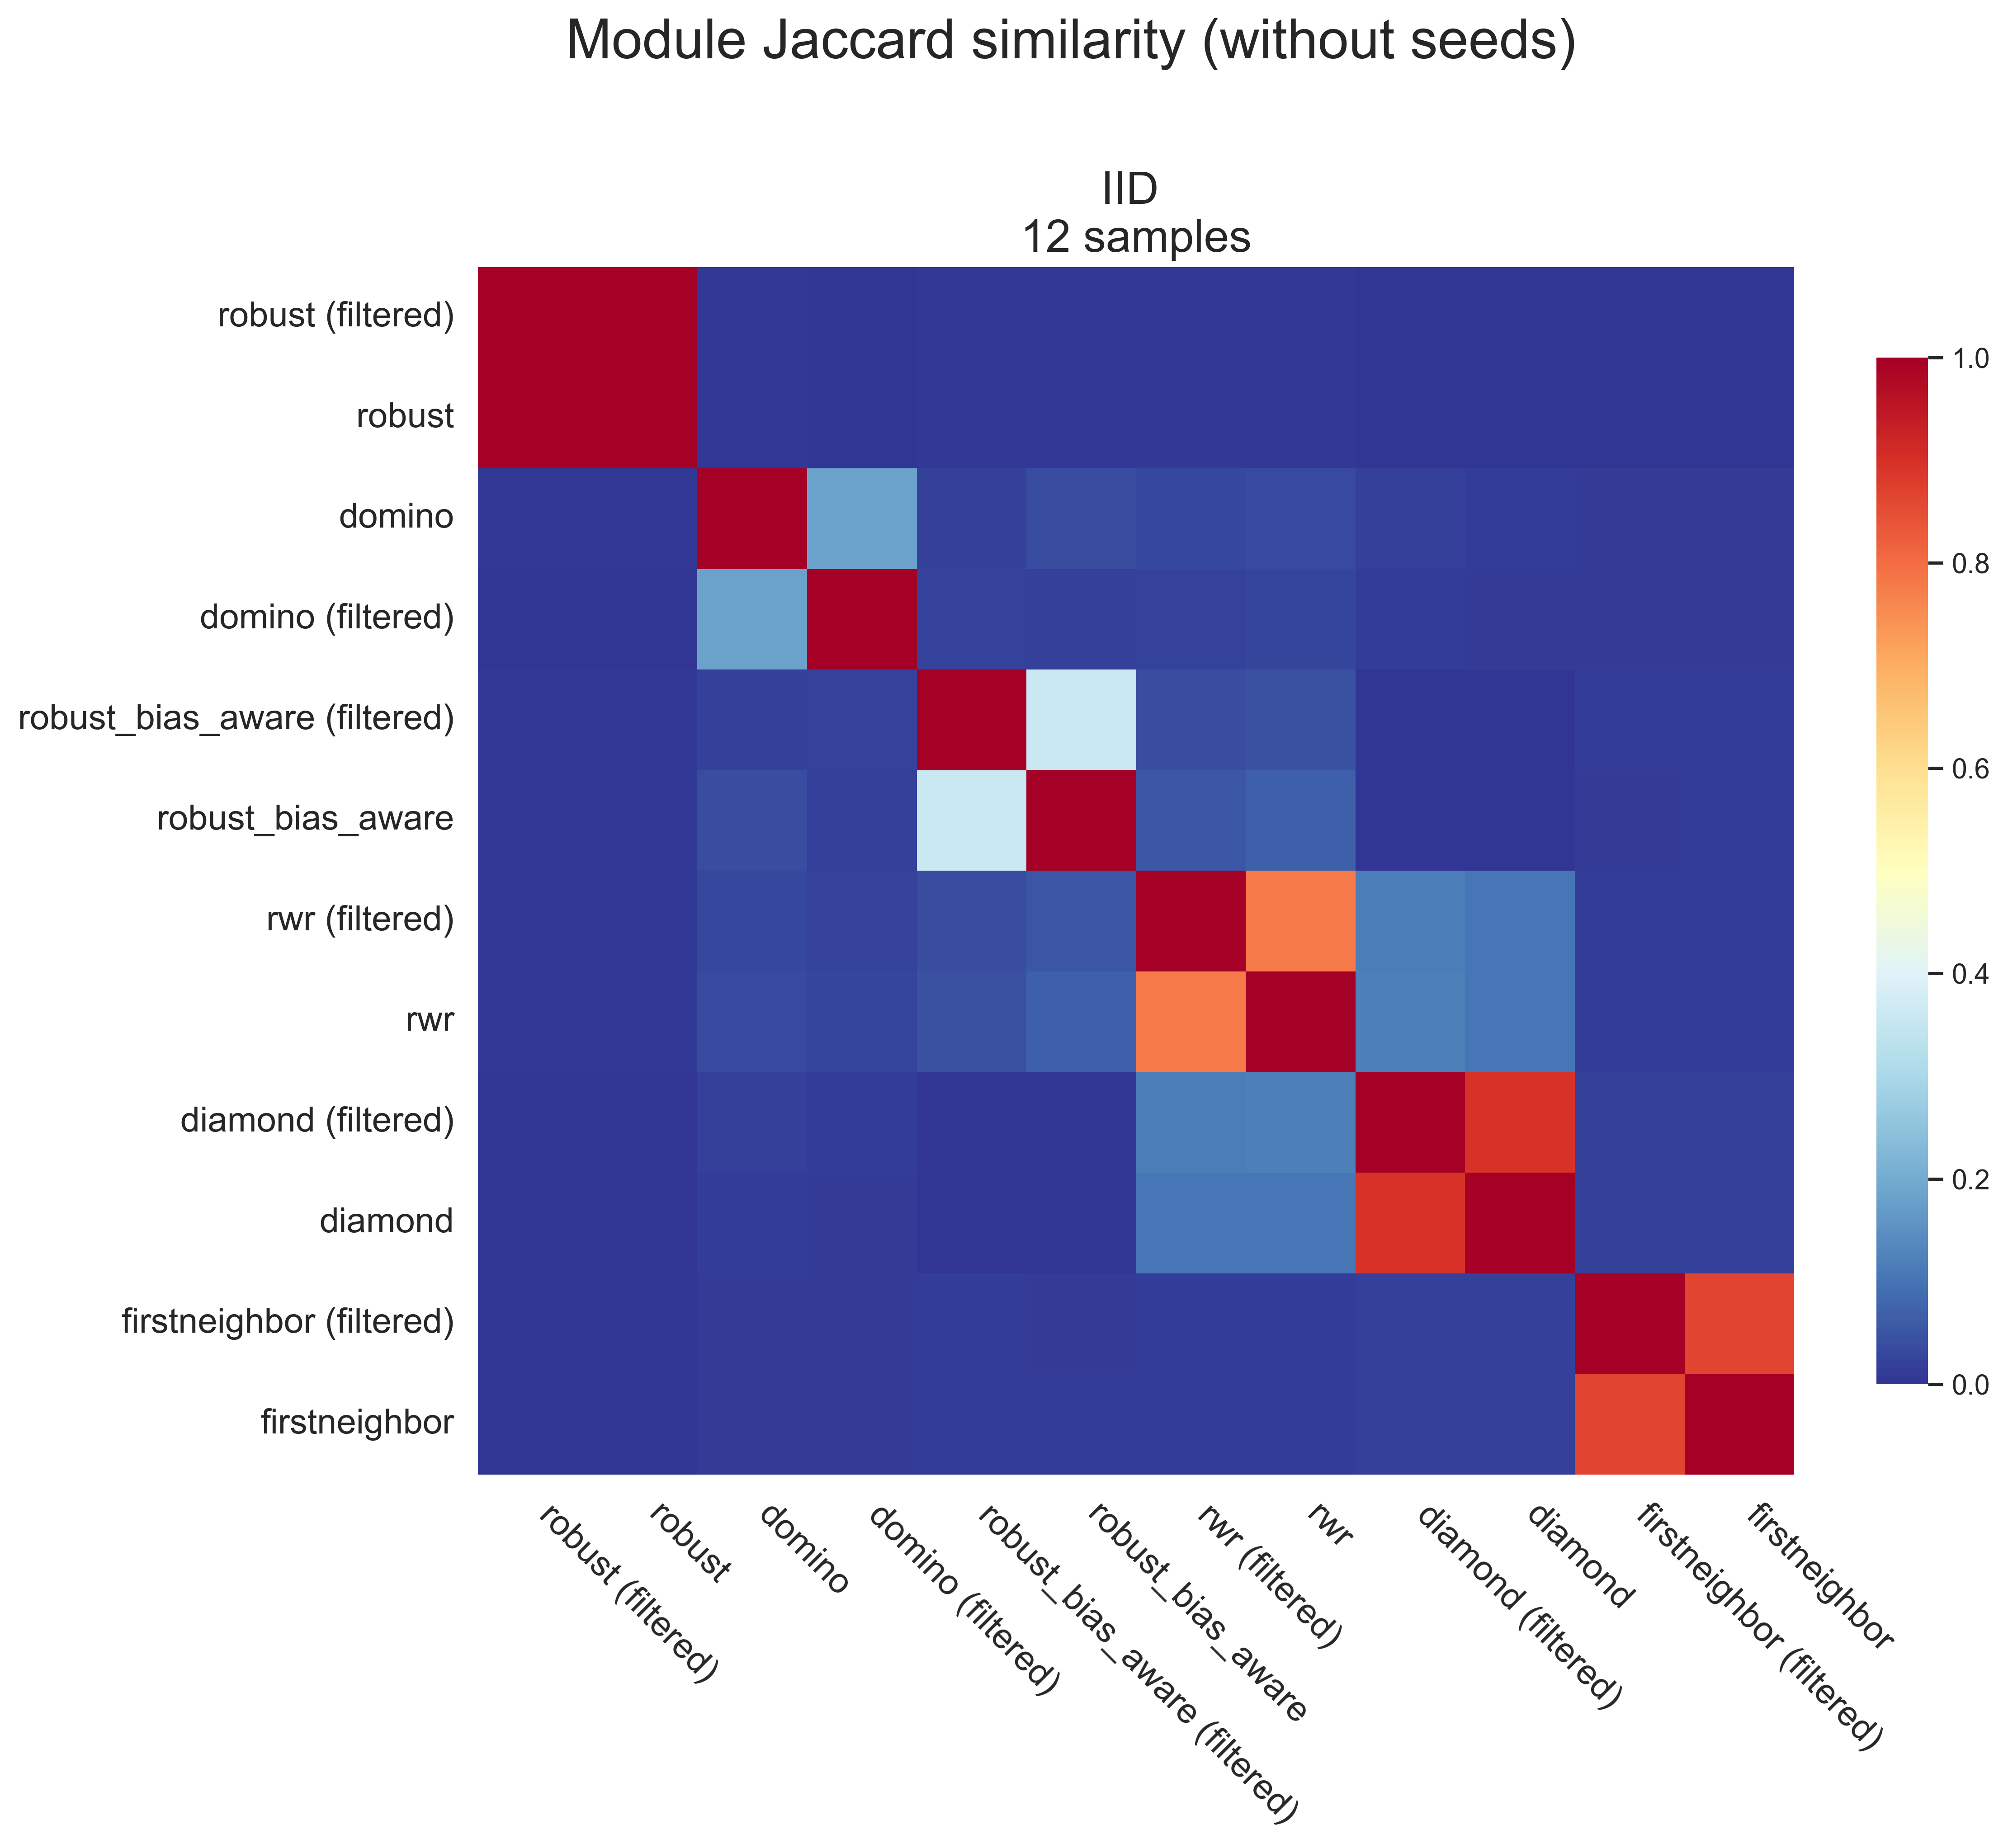

In [25]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform

similarity_path = "data/jaccard_similarity_no_seeds_matrix_mqc.tsv"
raw_similarity_df = pd.read_csv(similarity_path, sep="\t", index_col=0)

def simplify_sample_name(sample_name: str) -> str:
    parts = sample_name.split(".")
    tool = parts[-1]
    tissue = parts[-2] if len(parts) > 1 and "_" in parts[-2] else None
    return f"{tool} (filtered)" if tissue else tool

def cluster_similarity_matrix(df: pd.DataFrame) -> pd.DataFrame:
    if df.shape[0] <= 1:
        return df
    distance_df = 1 - df
    distance_df = (distance_df + distance_df.T) / 2
    for idx in range(len(distance_df)):
        distance_df.iat[idx, idx] = 0.0
    linkage_matrix = linkage(squareform(distance_df.to_numpy()), method="average", optimal_ordering=True)
    cluster_order = leaves_list(linkage_matrix)
    ordered_labels = df.index[cluster_order].tolist()
    return df.loc[ordered_labels, ordered_labels]

network_label = "iid"
network_token = ".iid."

selected_samples = [sample for sample in raw_similarity_df.index if network_token in sample]
network_df = raw_similarity_df.loc[selected_samples, selected_samples].copy()
simplified_labels = [simplify_sample_name(sample) for sample in network_df.index]
network_df.index = simplified_labels
network_df.columns = simplified_labels
clustered_network_df = cluster_similarity_matrix(network_df)

sns.set_theme(style="white")
fig, ax = plt.subplots(figsize=(12, 10), dpi=400, facecolor="white")
ax.set_facecolor("white")

sns.heatmap(
    clustered_network_df,
    cmap="RdYlBu_r",
    vmin=0,
    vmax=1,
    ax=ax,
    cbar_kws={"shrink": 0.85},
)

ax.set_title(f"{network_label.upper()} \n{clustered_network_df.shape[0]} samples", fontsize=18)
ax.set_xticklabels(ax.get_xticklabels(), rotation=-45, ha="left", fontsize=14)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=14)

fig.suptitle("Module Jaccard similarity (without seeds)", fontsize=22, y=1.02)
plt.tight_layout()
plt.show()